# Sensitivity of SPB Targets to Data, Assumptions and Rules

This notebook asks how much the SPB targets of the EU fiscal rules depend on the choices behind them. The baseline is close to the reference trajectories of the Commission prior guidance of 2024: it uses the input workbook built from the Commission calculation sheets and the Commission implementation of the rules (`rules='commission'`). All runs use the fiscal multiplier with a persistent effect on the output gap (`fiscal_multiplier_type='pers'`), whose persistence is one of the checks, instead of the output gap closure rule of the Commission sheets. Each check changes one input, assumption or rule and records how the SPB target at the end of the adjustment period responds, for all EU countries and for 4- and 7-year adjustment periods.

Each run records two targets:

- the **DSA target**: the SPB required by the DSA criteria alone (debt declines or stays below 60% in the deterministic scenarios, deficit below 3%, stochastic criterion);
- the **binding target**: the SPB after the excessive deficit procedure (EDP), the debt sustainability safeguard and the deficit resilience safeguard are added.

Most assumptions work through the DSA criteria, so sections 1 to 3 show the DSA target. Where the EDP or a safeguard binds, it can hide the effect of an assumption or add effects of its own; section 4 compares the two targets.

1. **One-at-a-time checks.** Each check is one row of the specification table: model arguments, model attributes, changes to the input data, options of `find_spb_binding` and optional setup functions. The checks cover data revisions, macroeconomic assumptions, the fiscal multiplier, the calibration of the stress tests, the stochastic analysis and the rules. Runs with nine other random seeds give a noise band.
2. **Bundles.** An accommodative and a strict bundle combine, for each setting, the variant that lowers or raises the median DSA target most. The bundles are defined from the results; neither is a preferred specification.
3. **Global sensitivity analysis.** 200 random draws of the continuous assumptions, deterministic criteria only, with a decomposition of the variance of the target by country.
4. **DSA criteria and safeguards.** How the EDP and the safeguards change the picture.
5. **Main findings.**
6. **Results tables**, saved to `output/sensitivity/`.

Each run records the target, the annual adjustment, the binding criterion, the SPB target of each criterion, net expenditure growth, debt 10 years after the adjustment period, and the gap to the next criterion: how far the target would fall if the binding criterion were dropped. Both targets come from the same run: `find_spb_binding` finds the DSA target first and then applies the EDP and the safeguards.

Runs are cached in `output/sensitivity/`: with `RUN = True`, the notebook computes only runs that are not in the cache. A full run takes about 1.5 hours on four cores (about 10 seconds per stochastic run). `QUICK = True` runs a subset of countries and fewer global draws for testing. The helper functions are in `code/functions/sensitivity.py`.

For comments and suggestions please contact lennard.welslau[at]gmail[dot]com.\
Last update: September 2026

In [1]:
# Import libraries and modules
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': 0.15, 'grid.linestyle': '--', 'font.size': 12,
                     'figure.dpi': 100, 'axes.titleweight': 'bold'})

# Import the DSA model classes and functions from the code folder
sys.path.append(os.path.abspath('..'))
from classes import StochasticDsaModel as DSA
from data_pipeline import EU27, latest_input_file
from functions.sensitivity import *

# Set autoreload
%load_ext autoreload
%autoreload 2

## Settings

In [2]:
INPUT_FILE = 'dsa_inputs_commission_2024.xlsx'  # baseline input workbook (Commission prior guidance 2024)
BASELINE_RULES = 'commission'                    # rules of find_spb_binding in the baseline
MULTIPLIER_TYPE = 'pers'                         # fiscal multiplier with persistent effect in all runs (None: input file)
ADJUSTMENT_PERIODS = (4, 7)
COUNTRIES = EU27
SEED = 0                                         # random seed set before every run (noise band: seeds 1 to 9)
N_DRAWS = 200                                    # draws of the global sensitivity analysis
FOCUS_COUNTRY = 'ITA'                            # country for the tornado chart and debt paths
MIN_EFFECT = 0.05                                # smallest median effect (pp.) for a variant to enter a bundle
MAX_WORKERS = None                               # worker processes, None uses all CPUs

QUICK = False                                    # True: subset of countries and fewer global draws (for testing)
QUICK_COUNTRIES = ['BEL', 'DEU', 'ESP', 'FRA', 'ITA', 'NLD']
RUN = True                                       # True: compute runs missing from the cache; False: use cached runs only

if QUICK:
    COUNTRIES, N_DRAWS = QUICK_COUNTRIES, 40

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
run_options = dict(countries=COUNTRIES, adjustment_periods=ADJUSTMENT_PERIODS, input_file=INPUT_FILE,
                   rules=BASELINE_RULES, seed=SEED, run=RUN, max_workers=MAX_WORKERS,
                   model_kwargs={'fiscal_multiplier_type': MULTIPLIER_TYPE} if MULTIPLIER_TYPE else None)

## 1. One-at-a-time checks

### 1.1 Specification table

Each row changes one setting relative to the baseline. Starting values such as the SPB, the balances and debt in T are data, not assumptions, and are not varied; the data revision check instead reruns all countries on the latest input workbook, in which the forecasts for T and the following years of the 2024 guidance are replaced by outturns. Input changes are relative to the baseline workbook: the notebook reads the baseline value with `read_country` and passes the new absolute value as an override. Potential growth is shifted together with baseline real growth, so that the output gap is unchanged. The ageing-cost check scales the change in ageing costs relative to T; the stock-flow check sets the stock-flow adjustment to zero after T.

Interest rate and inflation checks shift the model paths as if the T+10 or T+30 anchor were different, with the linear interpolation the model uses between anchors (`shift_anchor`). Changing the anchor parameters in the workbook would not work here: the Commission workbook provides full paths of market rates and inflation up to about T+20, and the model uses the anchor parameters only to fill years without data.

In [3]:
oat_specs = build_oat_specs(latest_file=latest_input_file())
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 70):
    display(spec_table(oat_specs))

,group,check,variant,model arguments,attributes,input changes,find_spb_binding options,setup,other
id,,,,,,,,,
baseline,Baseline,Baseline,baseline,,,,,,
data:latest,Data,Data revisions,latest vintage (2026_09),,,,,,input file dsa_inputs_2026_09.xlsx
macro:rate_st_T10:-1,Macro,Short-term rate T+10,-1,,,,,"shift_anchor(variable=i_st, anchor=10, delta=-1)",
macro:rate_st_T10:+1,Macro,Short-term rate T+10,+1,,,,,"shift_anchor(variable=i_st, anchor=10, delta=1)",
macro:rate_lt_T10:-1,Macro,Long-term rate T+10,-1,,,,,"shift_anchor(variable=i_lt, anchor=10, delta=-1)",
macro:rate_lt_T10:+1,Macro,Long-term rate T+10,+1,,,,,"shift_anchor(variable=i_lt, anchor=10, delta=1)",
macro:rate_st_T30:-0.5,Macro,Short-term rate T+30,-0.5,,,,,"shift_anchor(variable=i_st, anchor=30, delta=-0.5)",
macro:rate_st_T30:+0.5,Macro,Short-term rate T+30,+0.5,,,,,"shift_anchor(variable=i_st, anchor=30, delta=0.5)",
macro:rate_lt_T30:-0.5,Macro,Long-term rate T+30,-0.5,,,,,"shift_anchor(variable=i_lt, anchor=30, delta=-0.5)",


### 1.2 Runs

The baseline and every check run for each country and adjustment period. The Commission targets are added for comparison: the published SPB at the end of the adjustment period (after the safeguards) and the target from the DSA criteria alone.

In [4]:
oat = run_specs(oat_specs, cache_file=OUTPUT_DIR / 'oat_runs.pkl', **run_options)
vintage = 'latest' if 'latest' in INPUT_FILE else '2024'
oat = oat.merge(commission_targets(COUNTRIES, vintage=vintage), on=['country', 'adjustment_period'], how='left')
oat = add_deviations(oat)
noise = noise_band(oat, target='dsa')
checks = oat[oat['group'] != 'Baseline']
effects = check_effects(checks, target='dsa', noise=noise)
effects_binding = check_effects(checks, target='binding', noise=noise_band(oat, target='binding'))
print(f"{len(oat)} runs, {oat['error'].notna().sum() if 'error' in oat else 0} failed")

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


3618 runs, 0 failed


### 1.3 Baseline and Commission targets

The baseline is compared with the Commission targets, both from the DSA criteria alone and after the safeguards. The model reproduces them closely with the Commission's output gap closure rule (`MULTIPLIER_TYPE = None`, see `commission_replication.ipynb`); the persistent multiplier used here moves some targets by a few tenths of a percentage point.

In [5]:
base = oat[oat['id'] == 'baseline'].copy()
base['dsa difference'] = base['dsa_target'] - base['commission_dsa_target']
base['binding difference'] = base['binding_target'] - base['commission_target']
table = base.pivot_table(index='country', columns='adjustment_period', aggfunc='first',
                         values=['commission_dsa_target', 'dsa_target', 'dsa difference', 'commission_target',
                                 'binding_target', 'binding difference', 'binding_criterion'])
display(table.round(2))
for n in ADJUSTMENT_PERIODS:
    b = base[base['adjustment_period'] == n]
    print(f"{n}-year adjustment: median absolute difference {b['dsa difference'].abs().median():.2f} pp. (DSA target), "
          f"{b['binding difference'].abs().median():.2f} pp. (binding target); "
          f"maximum {b['dsa difference'].abs().max():.2f} and {b['binding difference'].abs().max():.2f} pp.")

binding difference                    binding_criterion  \
adjustment_period                  4     7                              4   
country                                                                     
AUT                            -0.36 -0.35                 debt_safeguard   
BEL                            -0.04 -0.04      debt_declines_adverse_r_g   
BGR                            -0.01  0.01              deficit_reduction   
CYP                             0.00  0.00                          floor   
CZE                             0.00 -0.07              deficit_reduction   
DEU                            -0.28 -0.35                 debt_safeguard   
DNK                             0.00 -0.56                          floor   
ESP                             0.00  0.00      debt_declines_adverse_r_g   
EST                             0.00  0.00                          floor   
FIN                            -1.04 -0.77                 debt_safeguard   
FRA                            -0.04 -0.11      debt_declines_adverse_r_g   
GRC                            -0.03 -0.18      debt_declines_adverse_r_g   
HRV                             0.00  0.00  debt_below_60_main_adjustment   
HUN                             0.00 -0.08      debt_declines_adverse_r_g   
IRL                              NaN   NaN              deficit_reduction   
ITA                            -0.04 -0.05      debt_declines_adverse_r_g   
LTU                             0.00 -0.07              deficit_reduction   
LUX                              NaN   NaN              deficit_reduction   
LVA                             0.01 -0.01              deficit_reduction   
MLT                            -0.01 -0.01              deficit_reduction   
NLD                             0.00 -0.07              deficit_reduction   
POL                            -0.08 -0.08              deficit_reduction   
PRT                             0.00 -0.21      debt_declines_adverse_r_g   
ROU                            -0.20 -0.14              deficit_reduction   
SVK                            -0.12 -0.21        debt_below_60_lower_spb   
SVN                             0.00 -0.07        debt_below_60_lower_spb   
SWE                             0.09 -0.37              deficit_reduction   

                                                 binding_target        \
adjustment_period                              7              4     7   
country                                                                 
AUT                               debt_safeguard           2.22  1.53   
BEL                    debt_declines_adverse_r_g           1.21  1.56   
BGR                            deficit_reduction          -0.88 -0.52   
CYP                                        floor           3.48  3.48   
CZE                            deficit_reduction           0.39  0.68   
DEU                               debt_safeguard           2.46  1.85   
DNK                            deficit_reduction          -1.09 -1.71   
ESP                    debt_declines_adverse_r_g           2.59  2.65   
EST                                        floor          -0.29 -0.29   
FIN                               debt_safeguard           4.83  4.02   
FRA                            deficit_reduction           0.75  1.11   
GRC                    debt_declines_adverse_r_g           2.58  2.64   
HRV                debt_below_60_main_adjustment          -0.36 -0.21   
HUN                    debt_below_60_adverse_r_g           2.67  3.23   
IRL                            deficit_reduction          -0.63 -0.62   
ITA                            deficit_reduction           3.31  3.27   
LTU                            deficit_reduction           0.27  0.12   
LUX                            deficit_reduction          -0.22 -0.32   
LVA                debt_below_60_main_adjustment          -0.13  0.17   
MLT                            deficit_reduction          -0.87 -0.03   
NLD                         

4-year adjustment: median absolute difference 0.04 pp. (DSA target), 0.01 pp. (binding target); maximum 0.28 and 1.04 pp.
7-year adjustment: median absolute difference 0.07 pp. (DSA target), 0.07 pp. (binding target); maximum 0.28 and 0.77 pp.


### 1.4 Overview by country and check

Each cell shows the change of the DSA target relative to the baseline, in percentage points of GDP (blue: lower target, red: higher target). Black dots mark runs in which another DSA criterion becomes binding. Countries are ordered by their baseline DSA target.

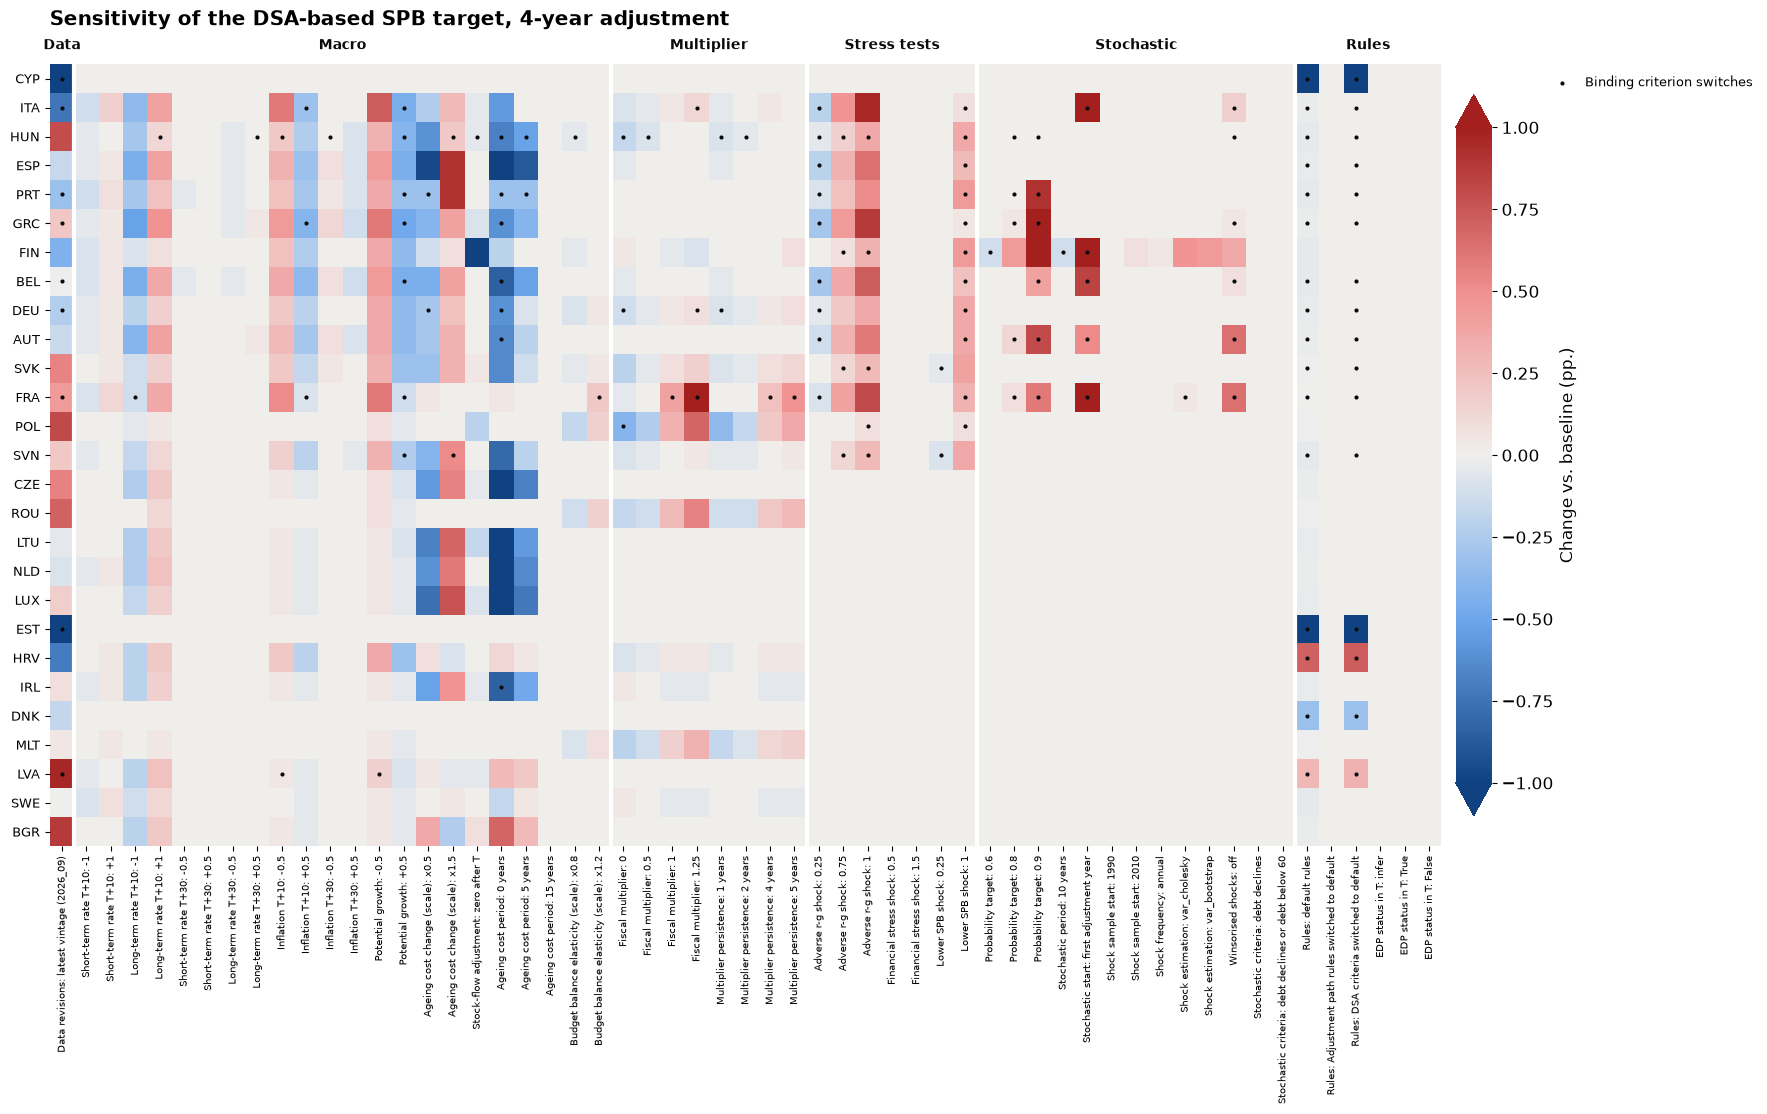

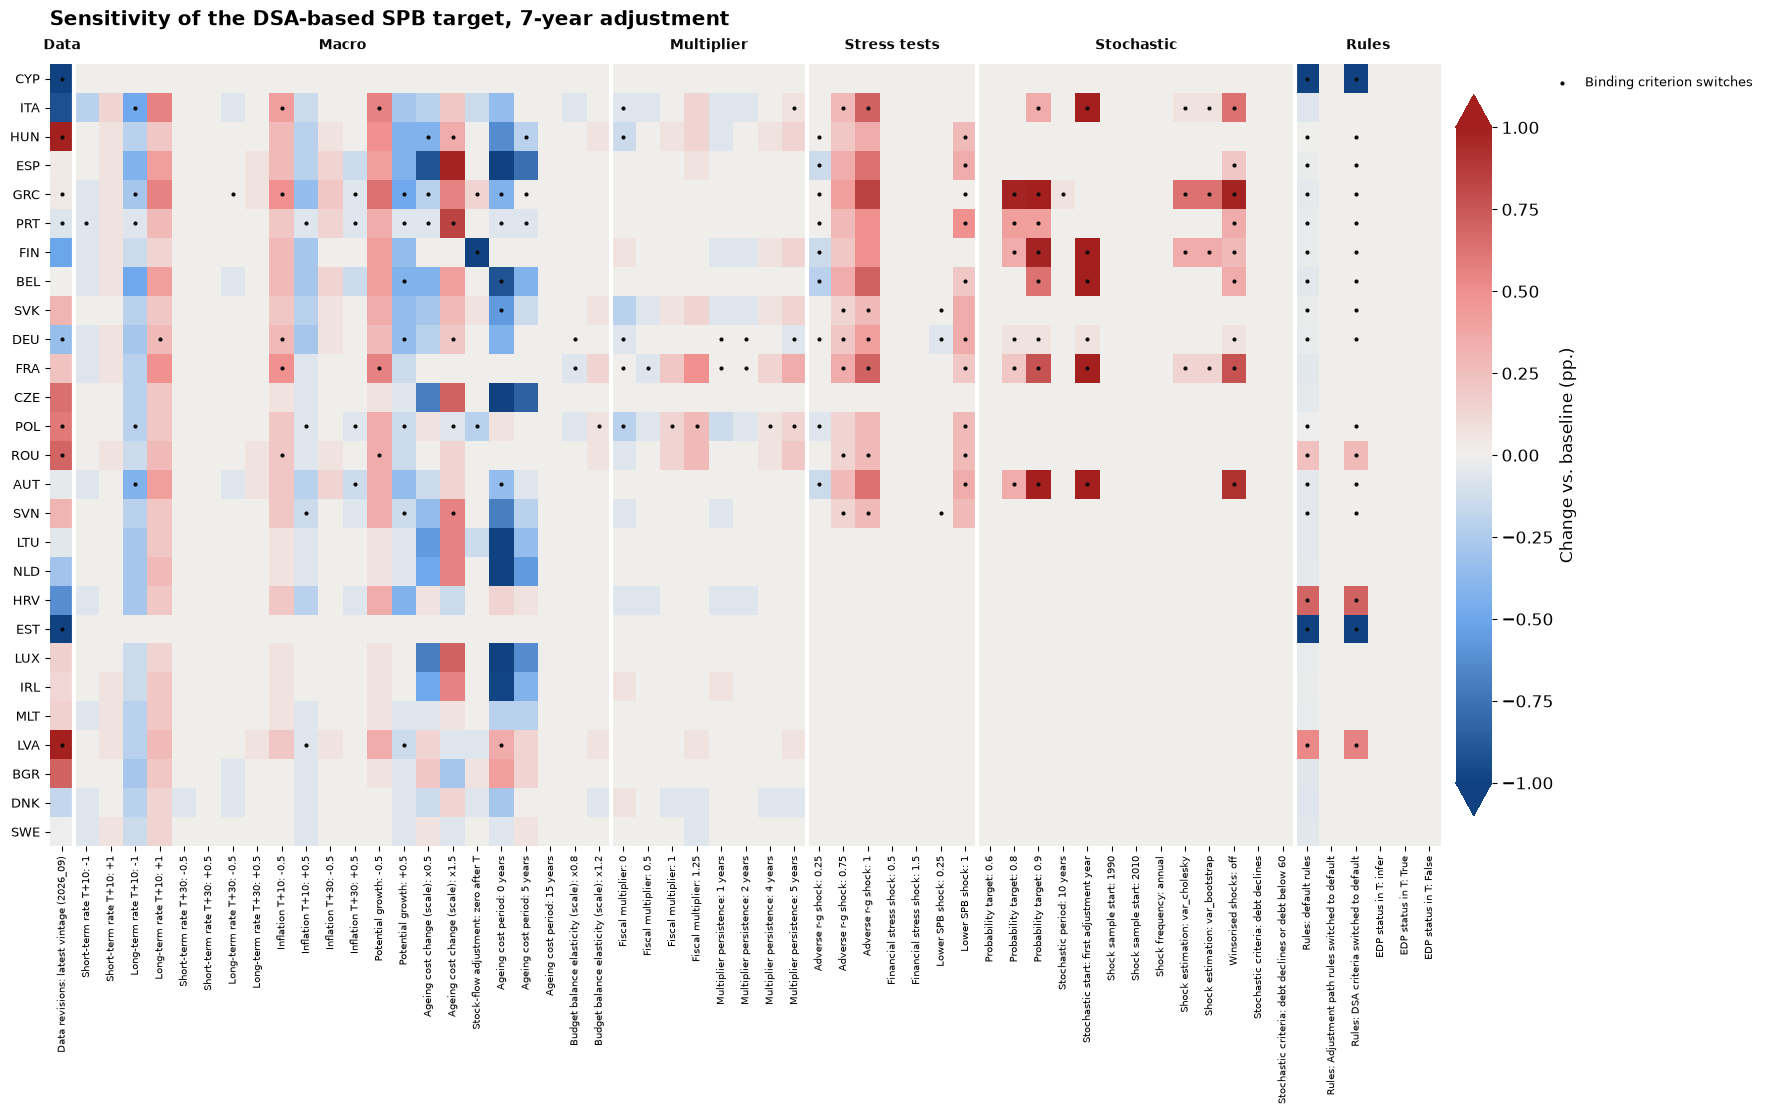

In [6]:
for n in ADJUSTMENT_PERIODS:
    plot_heatmap(oat[oat['group'] != 'Noise'], n, target='dsa')
    plt.show()

### 1.5 Which checks matter most

The tornado charts show, for each check, the lowest and highest change of the DSA target across its variants: the median across countries on the left and the focus country on the right. The grey band is the range across ten random seeds, the noise of the stochastic criterion. Effects inside the band are indistinguishable from simulation noise.

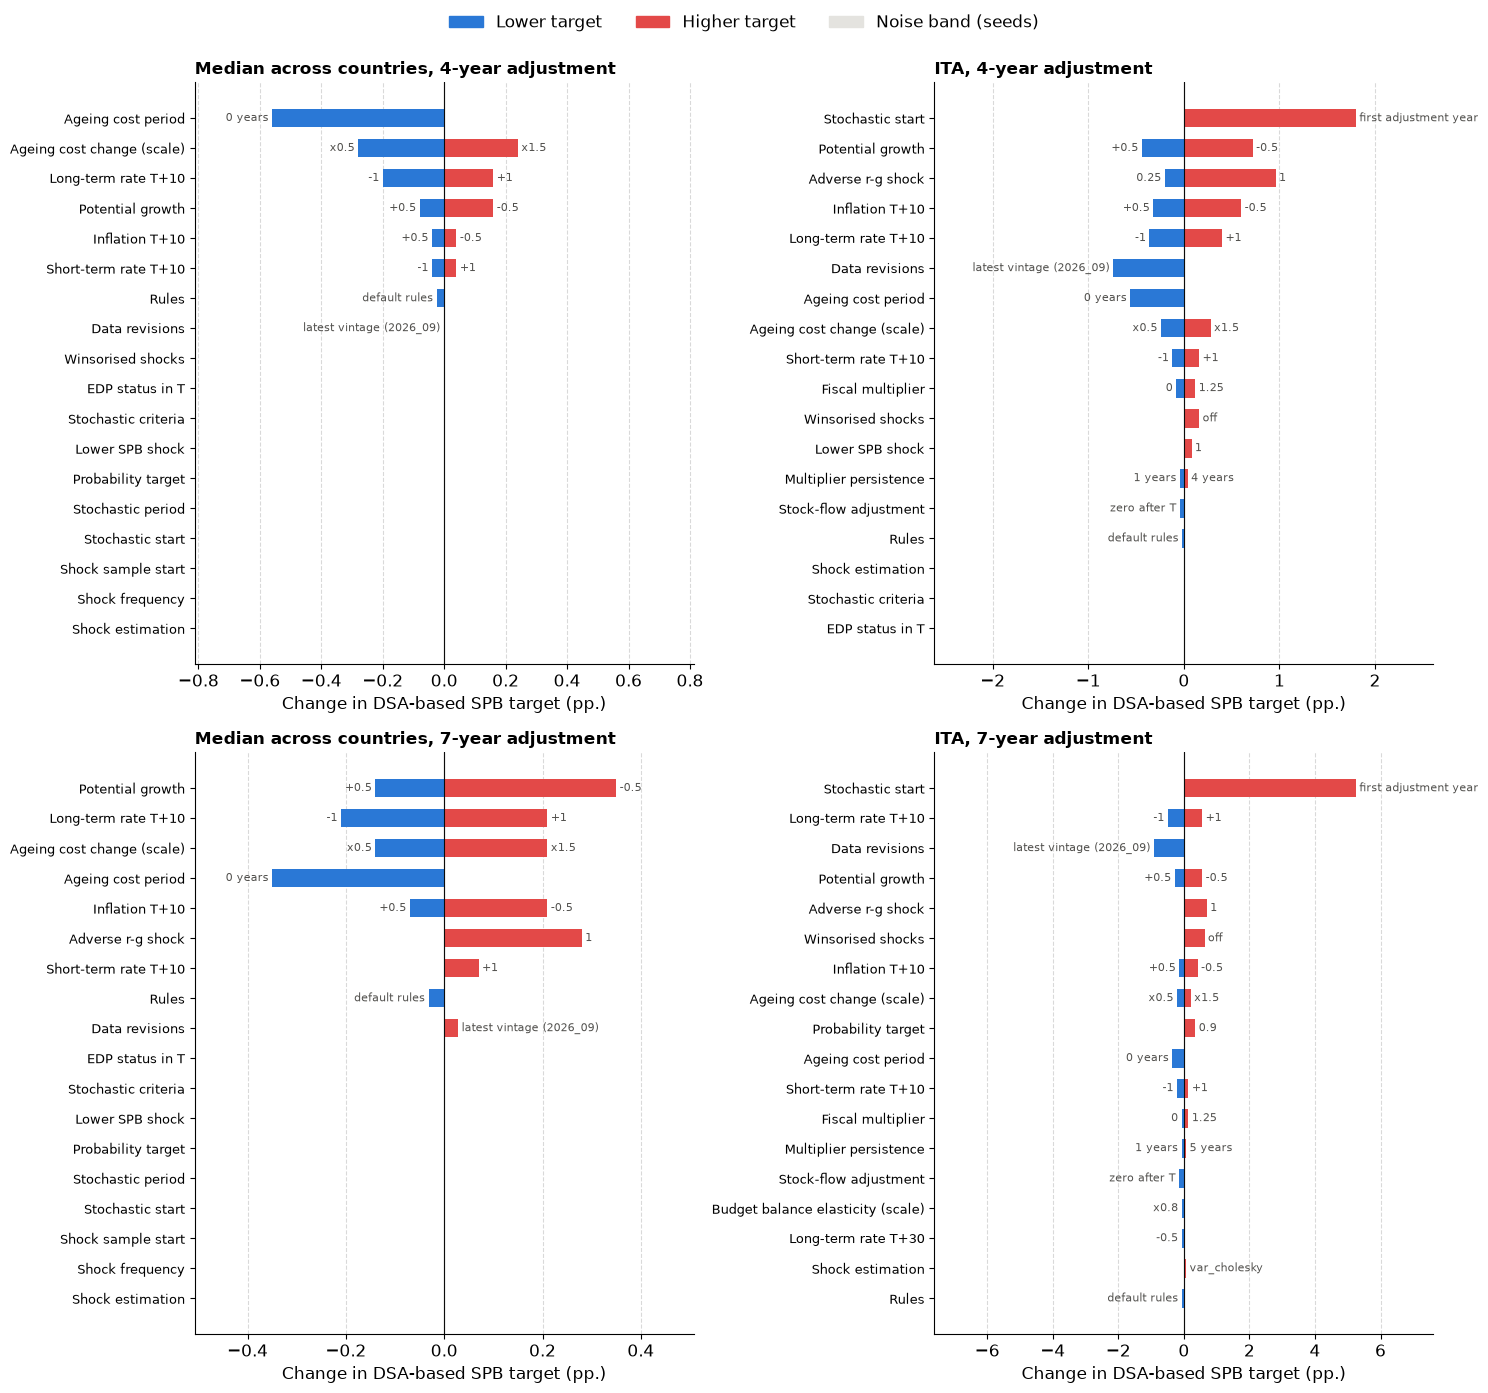

In [7]:
def tornado_grid(target):
    fig, axes = plt.subplots(len(ADJUSTMENT_PERIODS), 2, figsize=(15, 7 * len(ADJUSTMENT_PERIODS)))
    for row, n in zip(np.atleast_2d(axes), ADJUSTMENT_PERIODS):
        plot_tornado(oat, noise_band(oat, target), country=None, adjustment_period=n, target=target, ax=row[0])
        plot_tornado(oat, noise_band(oat, target), country=FOCUS_COUNTRY, adjustment_period=n, target=target, ax=row[1])
    handles = [Patch(color=LOWER, label='Lower target'), Patch(color=HIGHER, label='Higher target'),
               Patch(color=LIGHT_GREY, label='Noise band (seeds)')]
    fig.legend(handles=handles, loc='upper center', ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

tornado_grid('dsa')

In [8]:
# Effects on the DSA target by check variant: median, interquartile range and largest absolute change across countries
# and periods, share of runs with a switch of the binding criterion
with pd.option_context('display.max_rows', 200):
    display(effects.drop(columns='knob').set_index('id').sort_values('max_abs', ascending=False).round(2))

,group,check,variant,median,q25,q75,max_abs,criterion_switches,runs,noise
id,,,,,,,,,,
stochastic:start:adjustment,Stochastic,Stochastic start,first adjustment year,0.00,0.00,0.00,5.25,0.20,54,0.0
data:latest,Data,Data revisions,latest vintage (2026_09),0.02,-0.21,0.41,4.04,0.33,54,0.0
rules:default,Rules,Rules,default rules,-0.03,-0.04,-0.02,3.49,0.59,54,0.0
rules:switch:DSA criteria,Rules,Rules,DSA criteria switched to default,0.00,0.00,0.00,3.43,0.59,54,0.0
stochastic:prob_target:0.9,Stochastic,Probability target,0.9,0.00,0.00,0.05,2.38,0.26,54,0.0
macro:ageing_cost_period:0,Macro,Ageing cost period,0 years,-0.35,-0.83,0.00,1.89,0.24,54,0.0
macro:stock_flow_zero,Macro,Stock-flow adjustment,zero after T,0.00,-0.04,0.00,1.48,0.07,54,0.0
multiplier:fiscal_multiplier:1.25,Multiplier,Fiscal multiplier,1.25,0.00,0.00,0.07,1.00,0.07,54,0.0
macro:ageing_scale:x1.5,Macro,Ageing cost change (scale),x1.5,0.21,0.00,0.56,0.98,0.13,54,0.0


### 1.6 Response curves

For the numeric assumptions, the change of the DSA target by value of the assumption. Grey lines are countries, the black line is the median across countries, the orange line the focus country. Kinks show where the binding criterion switches.

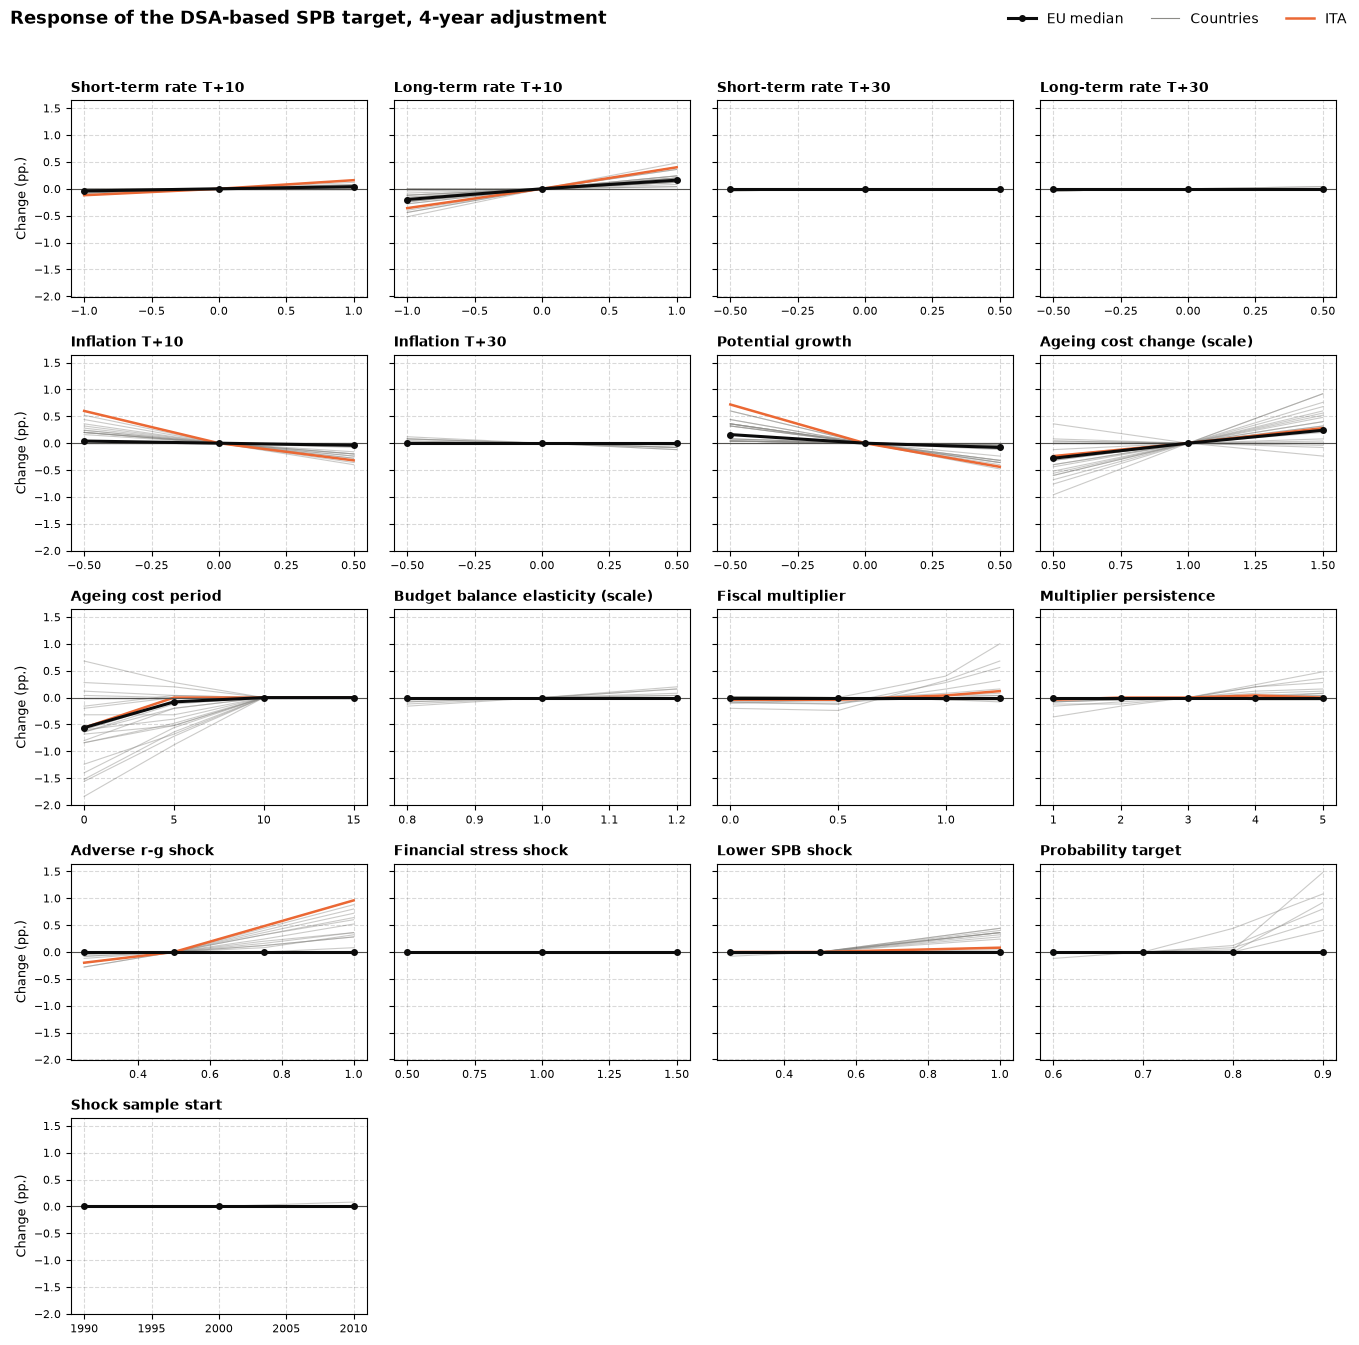

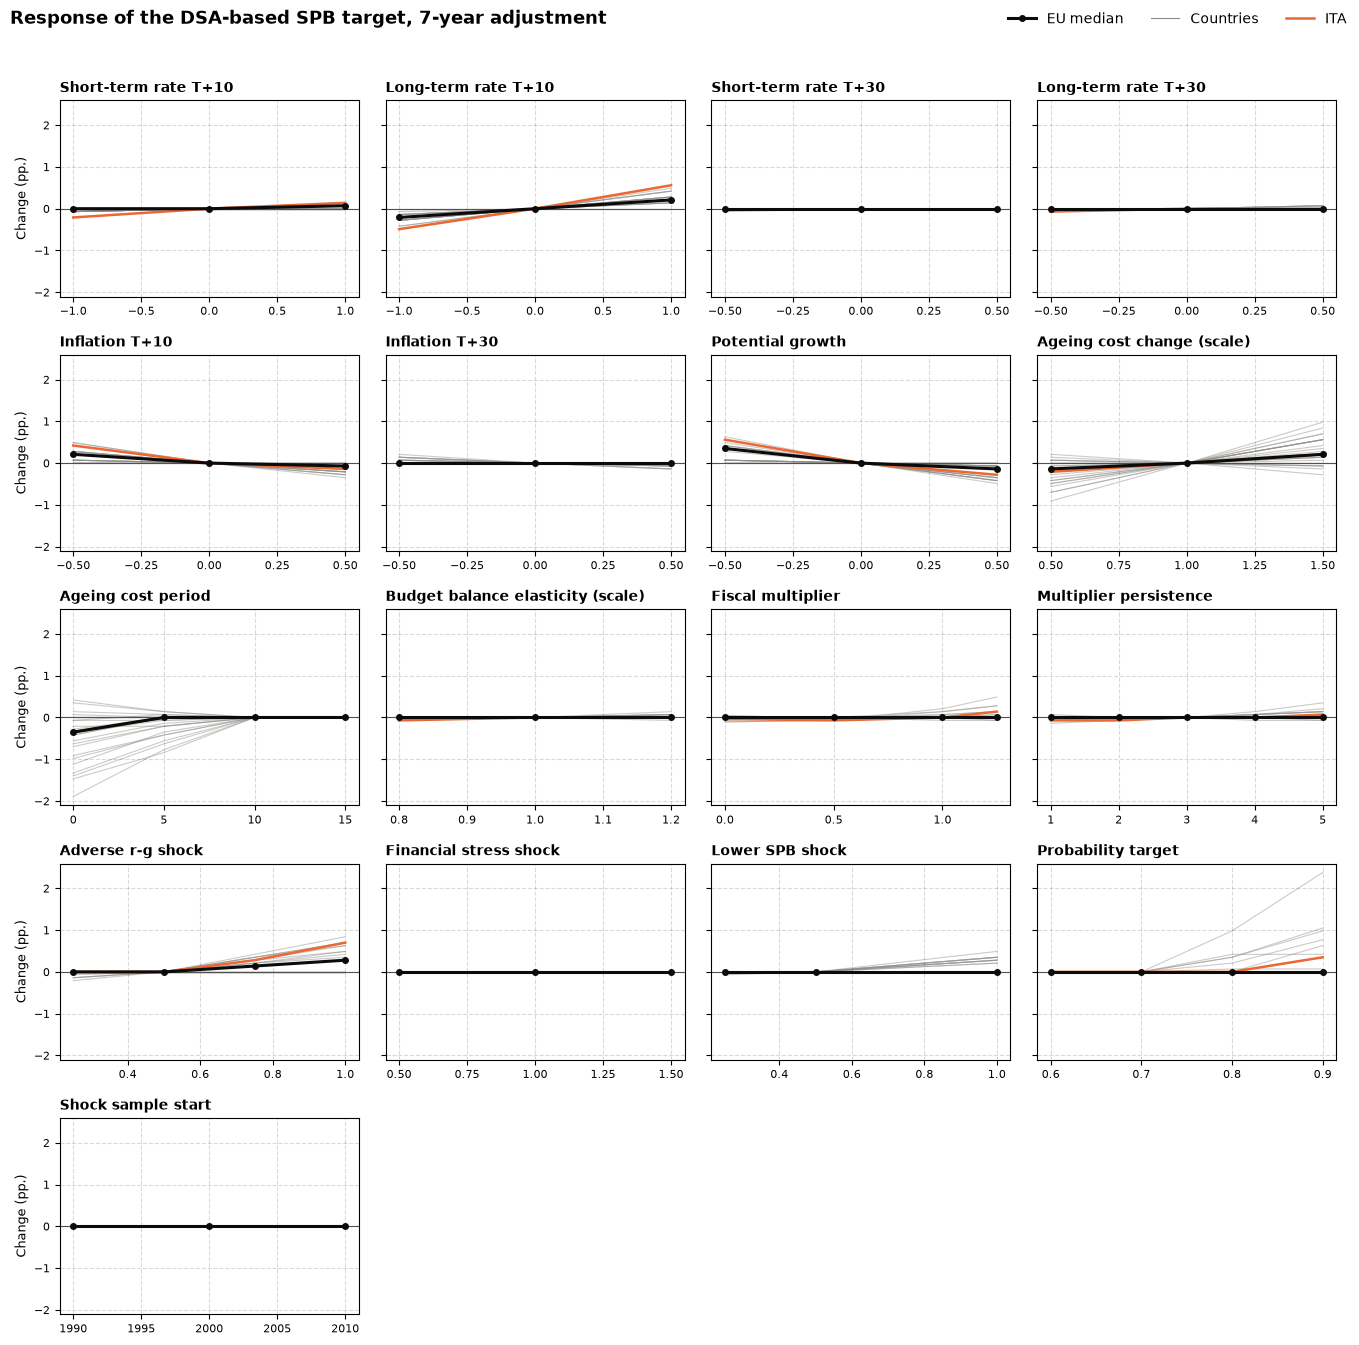

In [9]:
for n in ADJUSTMENT_PERIODS:
    plot_response_curves(oat, oat_specs, adjustment_period=n, target='dsa', highlight=FOCUS_COUNTRY)
    plt.show()

### 1.7 Binding DSA criteria

Share of runs by binding DSA criterion, for the baseline and across the variants of each check.

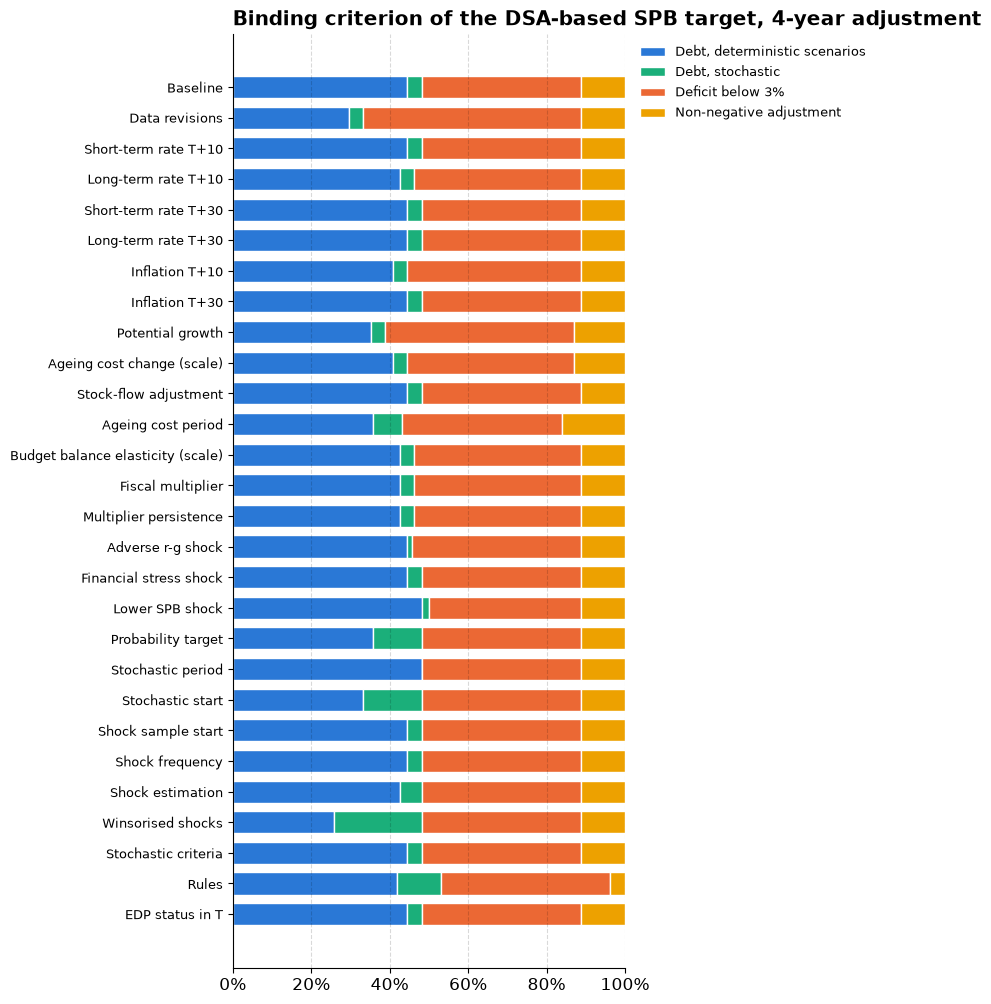

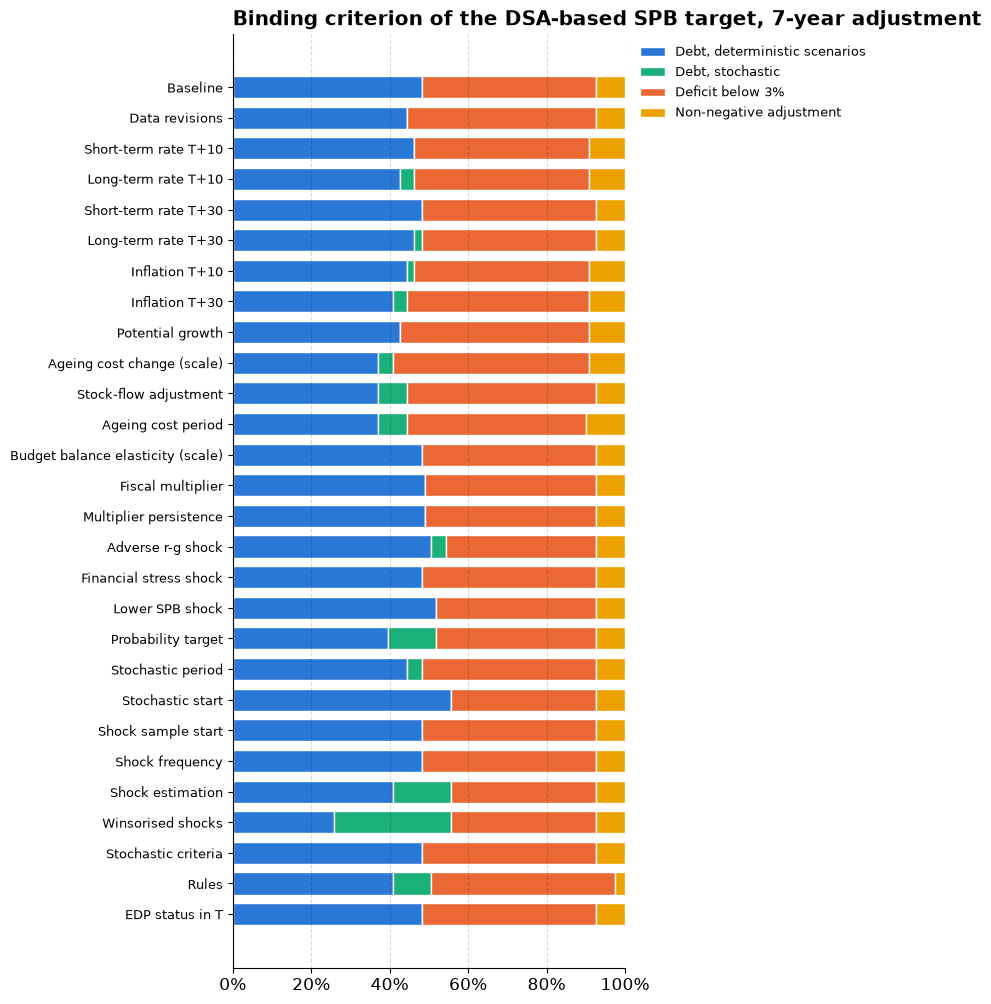

In [10]:
for n in ADJUSTMENT_PERIODS:
    plot_criterion_shares(oat, adjustment_period=n, target='dsa')
    plt.show()

## 2. Bundles

For each setting, the accommodative bundle takes the variant that lowers the median DSA target most, the strict bundle the variant that raises it most, if the effect exceeds half of the median noise band and `MIN_EFFECT`. In the baseline the noise band is close to zero, because the stochastic criterion is rarely binding and the Commission rules round the annual adjustment to 0.01 pp. The data revision check, the seeds and an EDP status that contradicts the Council decision (`edp_status=True/False`) are excluded: they are facts, not assumptions a user can choose. If two variants set the same option (e.g. the stochastic criteria via the rules and directly), the variant with the larger effect is kept.

In [11]:
noise_halfwidth = float((noise['noise_high'] - noise['noise_low']).median() / 2)
accommodative, strict, bundle_table = define_bundles(oat, oat_specs, noise_halfwidth, min_effect=MIN_EFFECT, target='dsa')
print(f'Noise half-width: {noise_halfwidth:.3f} pp.')
display(bundle_table.round(3))

Noise half-width: 0.000 pp.


,bundle,check,variant,median,status,id
0,accommodative,Ageing cost period,0 years,-0.35,included,macro:ageing_cost_period:0
1,accommodative,Long-term rate T+10,-1,-0.21,included,macro:rate_lt_T10:-1
2,accommodative,Ageing cost change (scale),x0.5,-0.21,included,macro:ageing_scale:x0.5
3,accommodative,Potential growth,+0.5,-0.13,included,macro:potential_growth:+0.5
4,accommodative,Inflation T+10,+0.5,-0.07,included,macro:inflation_T10:+0.5
5,strict,Inflation T+10,-0.5,0.20,included,macro:inflation_T10:-0.5
6,strict,Ageing cost change (scale),x1.5,0.21,included,macro:ageing_scale:x1.5
7,strict,Long-term rate T+10,+1,0.21,included,macro:rate_lt_T10:+1
8,strict,Potential growth,-0.5,0.32,included,macro:potential_growth:-0.5


In [12]:
bundles = run_specs([accommodative, strict], cache_file=OUTPUT_DIR / 'bundle_runs.pkl', **run_options)
commission = oat.loc[oat['id'] == 'baseline', ['country', 'adjustment_period', 'commission_target', 'commission_dsa_target']]
bundles = bundles.merge(commission, on=['country', 'adjustment_period'], how='left')
results = add_deviations(pd.concat([oat, bundles], ignore_index=True))
ids = ['baseline', 'bundle:accommodative', 'bundle:strict']
summary = results[results['id'].isin(ids)].pivot_table(index=['adjustment_period', 'country'], columns='id',
                                                       values=['dsa_target', 'binding_target'], aggfunc='first')
display(summary.round(2))
for target in ['dsa_target', 'binding_target']:
    spread = summary[(target, 'bundle:strict')] - summary[(target, 'bundle:accommodative')]
    print(f'Strict minus accommodative bundle, {target}:')
    print(spread.groupby('adjustment_period').describe().round(2))

binding_target                                     \
id                              baseline bundle:accommodative bundle:strict   
adjustment_period country                                                     
4                 AUT               2.22                 1.06          3.42   
                  BEL               1.21                 0.25          2.73   
                  BGR              -0.88                -0.77         -0.89   
                  CYP               3.48                 3.48          3.48   
                  CZE               0.39                 0.13          1.27   
                  DEU               2.46                 1.62          3.34   
                  DNK              -1.09                -1.09         -0.85   
                  ESP               2.59                 0.75          4.55   
                  EST              -0.29                -0.29         -0.29   
                  FIN               4.83                 3.67          5.99   
                  FRA               0.75                 0.55          2.19   
                  GRC               2.58                 2.13          4.17   
                  HRV              -0.36                -0.36          0.20   
                  HUN               2.67                 1.98          3.59   
                  IRL              -0.63                -1.47          0.09   
                  ITA               3.31                 2.35          5.31   
                  LTU               0.27                -0.15          1.23   
                  LUX              -0.22                -1.12          0.74   
                  LVA              -0.13                -0.16         -0.01   
                  MLT              -0.87                -0.89         -0.85   
                  NLD               0.08                -0.44          1.00   
                  POL               0.59                 0.51          0.99   
                  PRT               2.52                 2.20          4.20   
                  ROU               0.27                 0.19          0.63   
                  SVK               0.82                -0.50          1.78   
                  SVN               0.52                 0.03          1.52   
                  SWE              -0.74                -1.01         -0.59   
7                 AUT               1.53                 0.41          2.79   
                  BEL               1.56                 1.06          2.80   
                  BGR              -0.52                -0.50         -0.51   
                  CYP               3.48                 3.48          3.48   
                  CZE               0.68                 0.02          1.73   
                  DEU               1.85                 0.87          2.76   
                  DNK              -1.71                -1.28         -1.36   
                  ESP               2.65                 0.90          4.61   
                  EST              -0.29                -0.29         -0.29   
                  FIN               4.02                 2.90          5.21   
                  FRA               1.11                 0.77          2.84   
                  GRC               2.64                 2.23          4.53   
                  HRV              -0.21                -0.21          0.49   
                  HUN               3.23                 2.66          4.02   
                  IRL              -0.62                -1.00          0.15   
                  ITA               3.27                 2.67          4.97   
                  LTU               0.12                -0.22          1.03   
                  LUX              -0.32                -0.95          0.59   
                  LVA               0.17                -0.09          0.27   
                  MLT              -0.03                -0.14          0.20   
                  NLD              -0.01                -0.53          0.90 

Strict minus accommodative bundle, dsa_target:
                   count  mean   std   min   25%   50%   75%   max
adjustment_period                                                 
4                   27.0  1.68  1.22 -0.48  0.52  2.00  2.50  4.60
7                   27.0  1.86  1.12 -0.07  0.98  2.03  2.66  4.62
Strict minus accommodative bundle, binding_target:
                   count  mean   std   min   25%   50%   75%   max
adjustment_period                                                 
4                   27.0  1.34  1.03 -0.12  0.43  1.49  2.02  3.80
7                   27.0  1.31  0.98 -0.29  0.51  1.43  1.98  3.71


### 2.1 Range of targets by country

The grey bar spans the targets of all one-at-a-time checks (seeds excluded). Markers show the Commission target, the model baseline, the two bundles and the SPB in T. The distance between the SPB in T and a target is the adjustment the target requires. The first chart shows DSA targets, the second binding targets (Commission target as published).

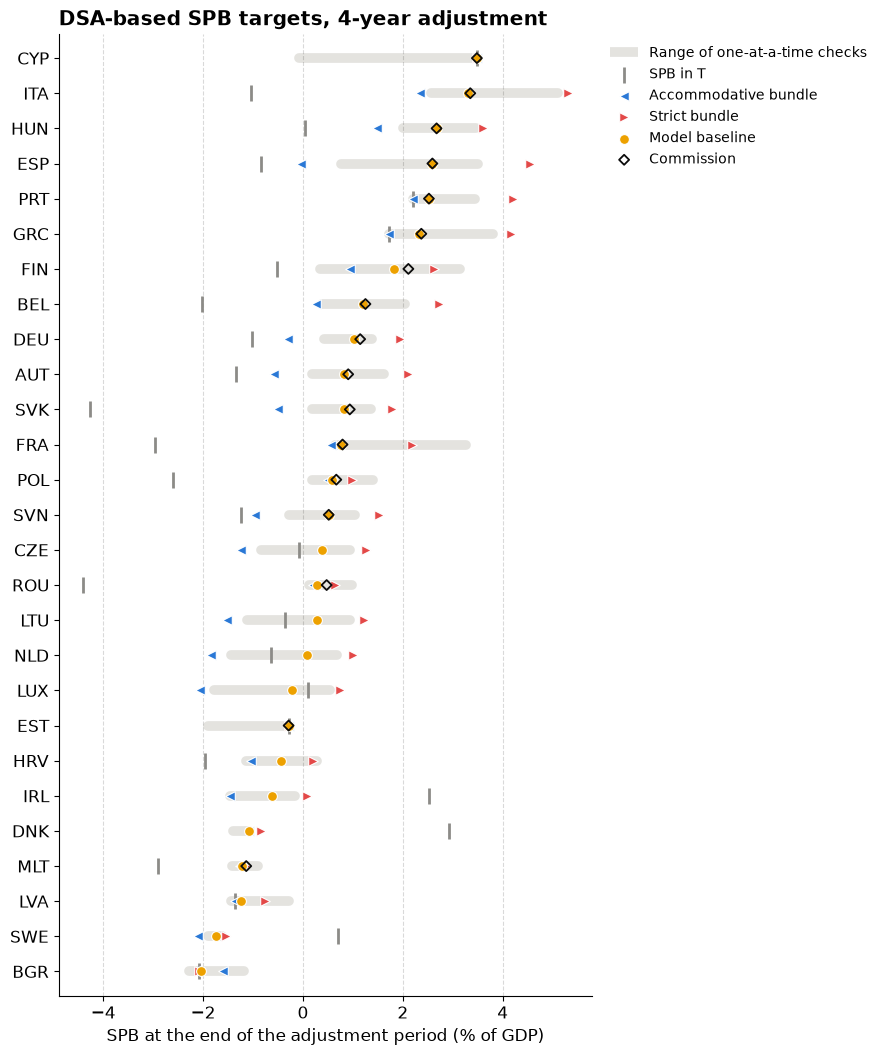

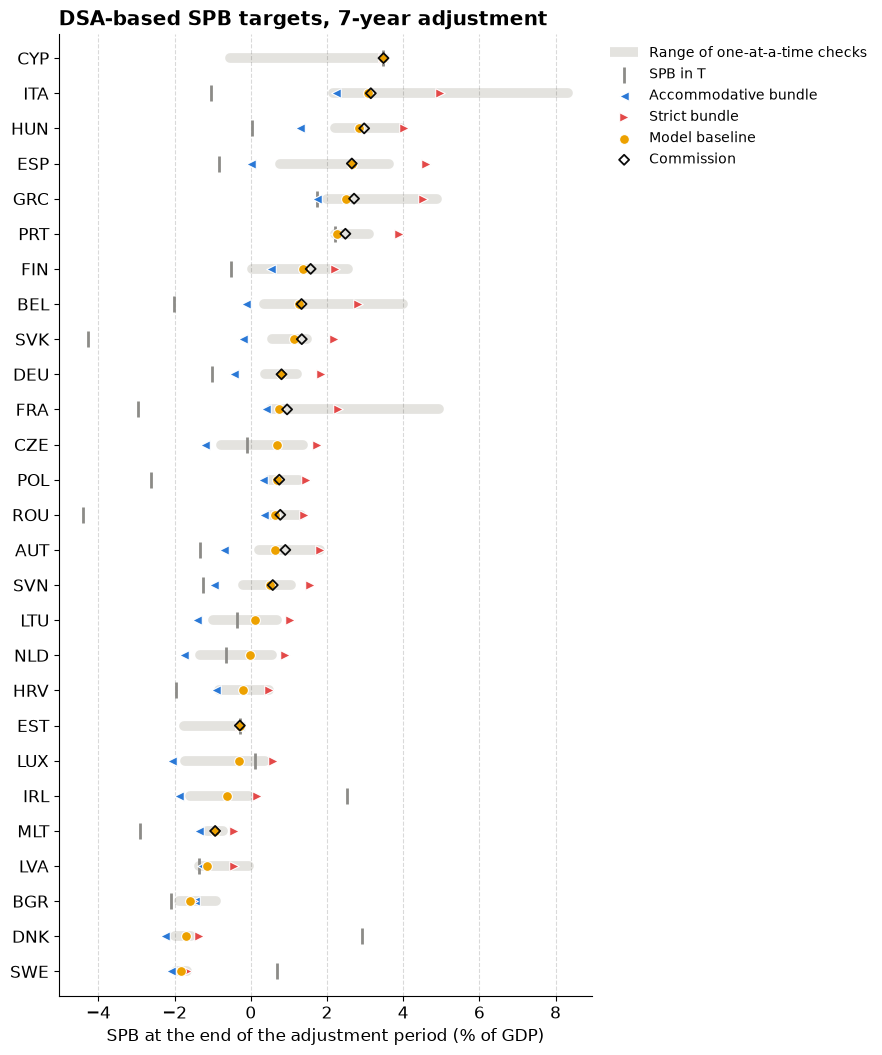

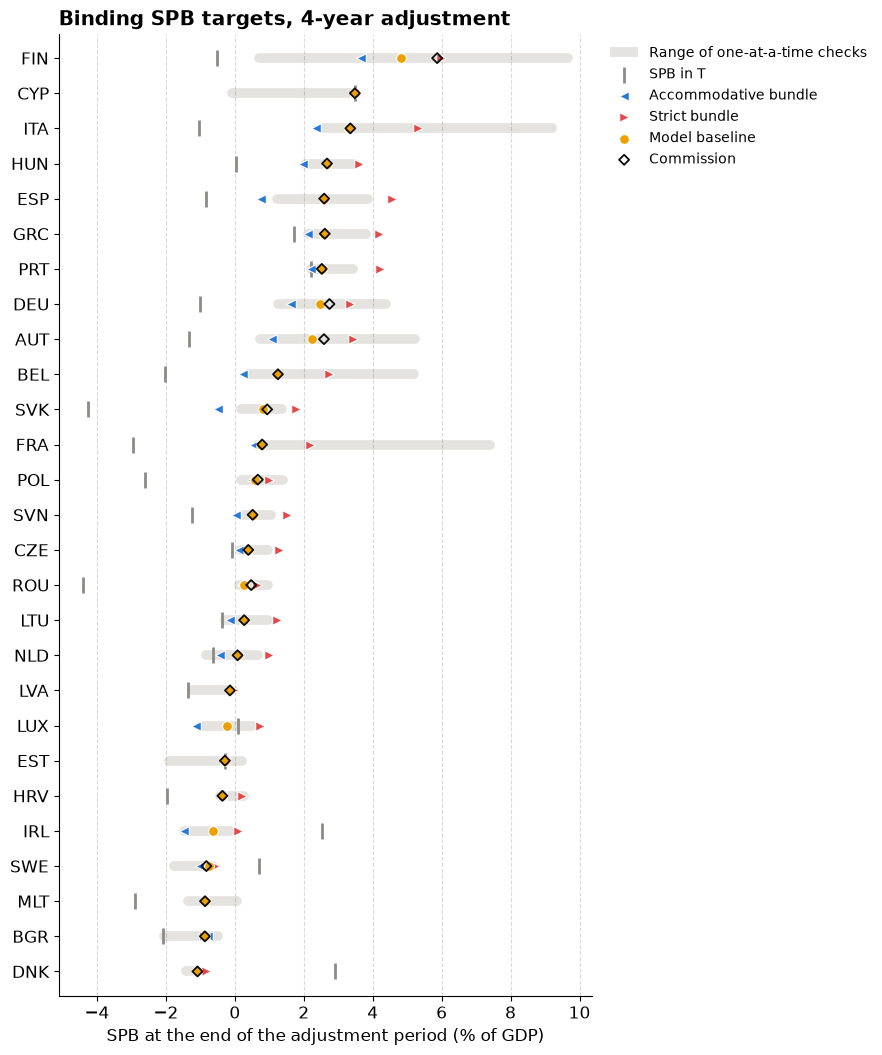

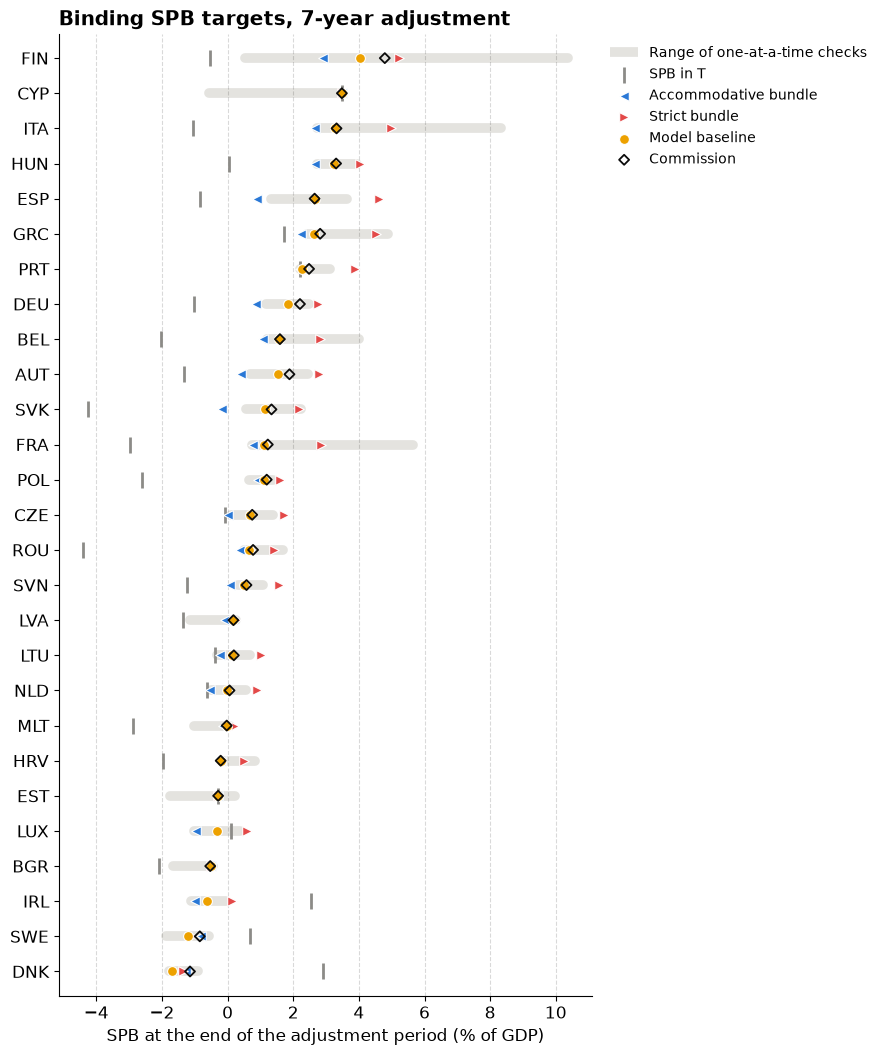

In [13]:
for target in ['dsa', 'binding']:
    for n in ADJUSTMENT_PERIODS:
        plot_ranges(results, n, target=target)
        plt.show()

### 2.2 Debt paths of the focus country

Debt under a linear adjustment to the DSA target of each run (the adjustment scenario under the assumptions of the run), with the baseline and the bundles highlighted.

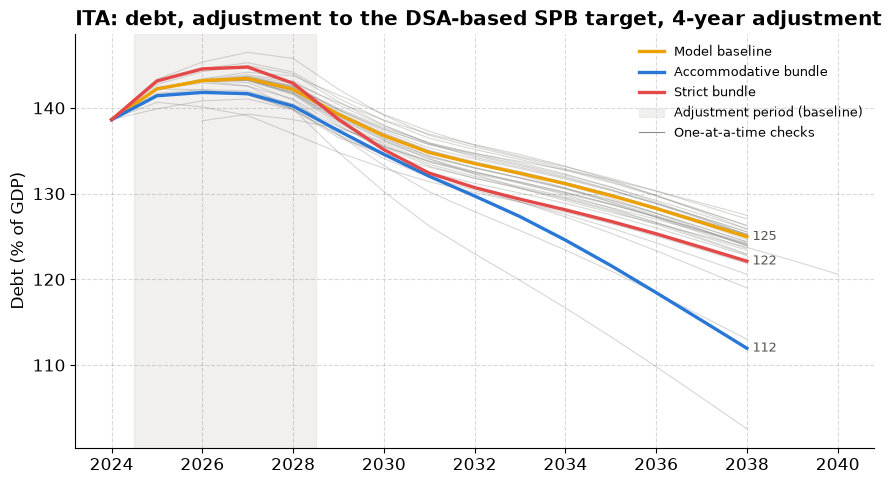

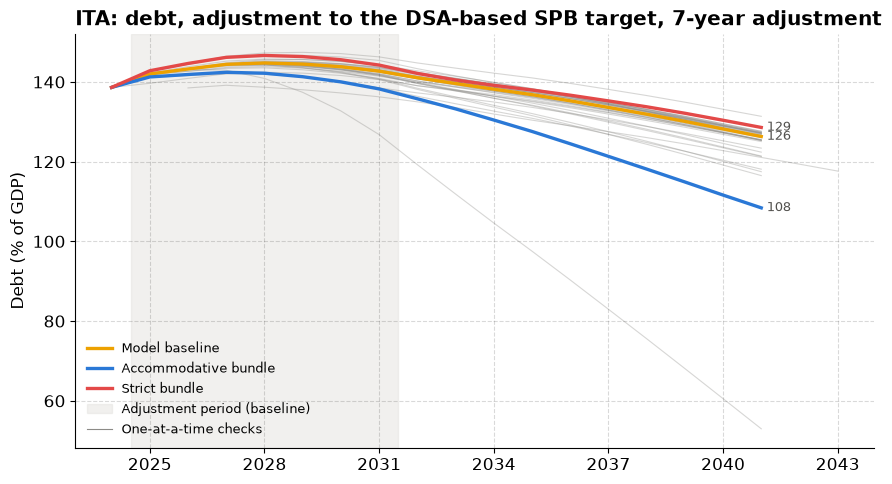

In [14]:
for n in ADJUSTMENT_PERIODS:
    plot_debt_paths(results, FOCUS_COUNTRY, adjustment_period=n, target='dsa')
    plt.show()

## 3. Global sensitivity analysis

One-at-a-time checks miss interactions: a higher interest rate may matter only once growth is low. The global analysis draws all continuous assumptions at once (Latin hypercube, over the range of the one-at-a-time values) and runs the deterministic criteria only (`stochastic=False`), which keeps the runs fast and free of simulation noise. The drawn values are recorded per run.

The variance of the target is split with squared standardised regression coefficients: the share of the variance explained linearly by each assumption, summed by category. The draws are close to uncorrelated, so the shares add up to the R² of the regression; the rest (grey) is due to non-linear effects and interactions, mostly switches of the binding criterion.

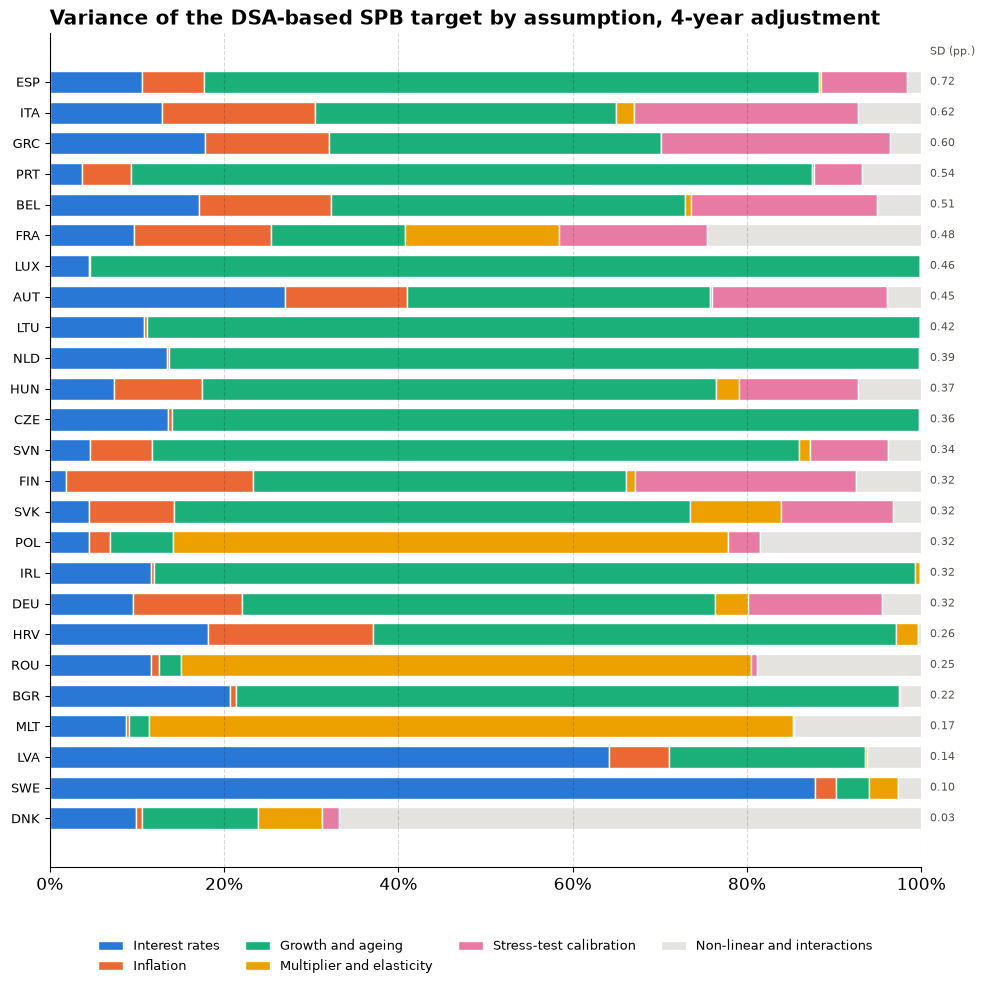

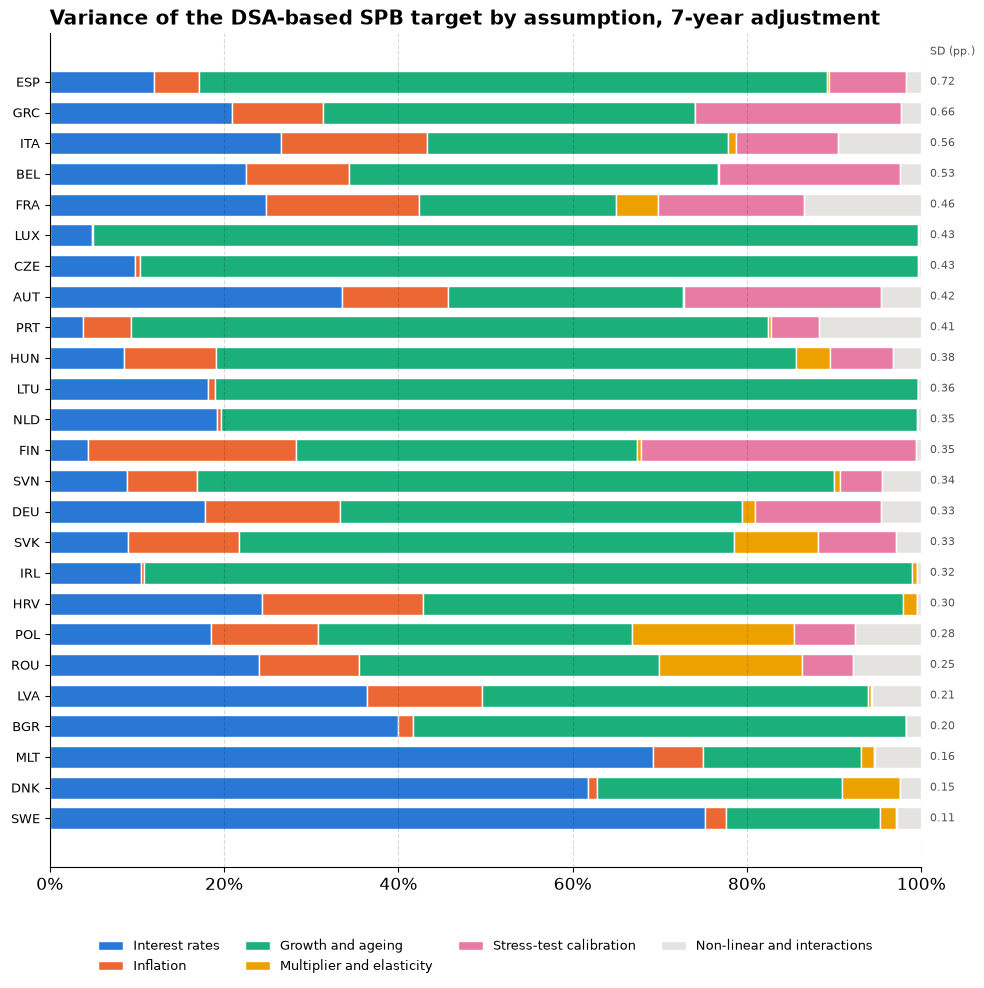

In [15]:
global_specs = build_global_specs(n_draws=N_DRAWS, seed=SEED)
glob = run_specs(global_specs, cache_file=OUTPUT_DIR / 'global_runs.pkl', **run_options)
glob = add_deviations(glob, baseline_id='baseline_deterministic')
draws = glob[glob['group'] == 'Global']
vd = pd.concat([variance_decomposition(draws, target='dsa'), variance_decomposition(draws, target='binding')],
               ignore_index=True)
for n in ADJUSTMENT_PERIODS:
    plot_variance_shares(vd[vd['target'] == 'dsa'], adjustment_period=n)
    plt.show()

In [16]:
# Largest single assumption per country (DSA target): share of variance and standard deviation of the target (pp.)
v = vd[vd['target'] == 'dsa'].set_index(['adjustment_period', 'country'])
src = v[[f'src2_{a}' for a in GLOBAL_ASSUMPTIONS]]
top = pd.DataFrame({'largest assumption': src.idxmax(axis=1).str.replace('src2_', ''), 'share': src.max(axis=1),
                    'r2': v['r2'], 'std (pp.)': v['std']})
display(top.round(2))
print(top.groupby('adjustment_period')['largest assumption'].value_counts())

,,largest assumption,share,r2,std (pp.)
adjustment_period,country,,,,
4,AUT,rate_lt_T10,0.25,0.96,0.45
7,AUT,rate_lt_T10,0.32,0.96,0.42
4,BEL,potential_growth,0.20,0.95,0.51
7,BEL,rate_lt_T10,0.21,0.98,0.53
4,BGR,ageing_scale,0.78,0.97,0.22
7,BGR,ageing_scale,0.55,0.98,0.20
4,CZE,ageing_scale,0.80,1.00,0.36
7,CZE,ageing_scale,0.85,1.00,0.43
4,DEU,potential_growth,0.37,0.95,0.32


adjustment_period  largest assumption
4                  ageing_scale          11
                   potential_growth       6
                   fiscal_multiplier      4
                   rate_lt_T10            3
                   adverse_r_g_shock      1
7                  potential_growth       9
                   ageing_scale           9
                   rate_lt_T10            6
                   adverse_r_g_shock      1
Name: count, dtype: int64


In [17]:
# Distribution of the targets across draws relative to the deterministic baseline (pp.)
q = draws.groupby(['adjustment_period', 'country'])[['dsa_delta_target', 'delta_target']].quantile([0.05, 0.5, 0.95])
q = q.unstack().rename(columns={'dsa_delta_target': 'DSA target', 'delta_target': 'binding target'})
display(q.round(2))

DSA target             binding target            
                                0.05  0.50  0.95           0.05  0.50  0.95
adjustment_period country                                                  
4                 AUT          -0.52  0.24  0.92          -1.32 -0.32  2.60
                  BEL          -0.64  0.24  1.12          -0.64  0.24  1.12
                  BGR          -0.28 -0.04  0.40          -0.07 -0.01  0.10
                  CYP           0.00  0.00  0.00           0.00  0.00  0.00
                  CZE          -0.60  0.00  0.60          -0.28  0.01  0.60
                  DEU          -0.40  0.16  0.68          -1.32 -0.28  1.76
                  DNK           0.00  0.00  0.08           0.00  0.00  0.08
                  ESP          -0.96  0.24  1.32          -0.88  0.32  1.44
                  EST           0.00  0.00  0.00           0.00  0.00  0.00
                  FIN          -0.32  0.24  0.76          -2.28 -0.64  4.25
                  FRA          -0.36  0.48  1.20          -0.36  0.48  1.20
                  GRC          -0.60  0.28  1.28          -0.45  0.21  1.03
                  HRV          -0.44  0.00  0.40           0.00  0.00  0.32
                  HUN          -0.60  0.08  0.64          -0.60  0.08  0.64
                  IRL          -0.52  0.00  0.52          -0.52  0.00  0.52
                  ITA          -0.56  0.28  1.44          -0.56  0.28  1.44
                  LTU          -0.68 -0.04  0.64          -0.48 -0.04  0.64
                  LUX          -0.72 -0.04  0.72          -0.72 -0.04  0.72
                  LVA          -0.20  0.00  0.28          -0.05  0.00  0.07
                  MLT          -0.24  0.00  0.28          -0.13 -0.00  0.02
                  NLD          -0.64  0.00  0.64          -0.60  0.00  0.64
                  POL          -0.44  0.00  0.68          -0.44  0.00  0.68
                  PRT          -0.32  0.26  1.24          -0.32  0.26  1.24
                  ROU          -0.28  0.00  0.52          -0.28  0.00  0.52
                  SVK          -0.44  0.16  0.64          -0.44  0.16  0.64
                  SVN          -0.48  0.18  0.64          -0.24  0.18  0.64
                  SWE          -0.16  0.00  0.16          -0.12  0.00  0.12
7                 AUT          -0.49  0.28  0.91          -0.84 -0.14  1.19
                  BEL          -0.70  0.21  1.12          -0.33  0.07  0.82
                  BGR          -0.35  0.00  0.35          -0.05  0.00  0.05
                  CYP           0.00  0.00  0.00           0.00  0.00  0.00
                  CZE          -0.70  0.00  0.70          -0.49  0.00  0.70
                  DEU          -0.42  0.14  0.70          -0.84 -0.14  0.91
                  DNK          -0.21  0.00  0.21          -0.14  0.07  0.79
                  ESP          -0.98  0.25  1.33          -0.98  0.28  1.33
                  EST           0.00  0.00  0.00           0.00  0.00  0.00
                  FIN          -0.49  0.14  0.70          -1.26 -0.28  1.34
                  FRA          -0.35  0.35  1.19          -0.31  0.13  0.82
                  GRC          -0.77  0.28  1.33          -0.16  0.24  1.19
                  HRV          -0.56 -0.07  0.49           0.00  0.00  0.49
                  HUN          -0.49  0.14  0.77          -0.34  0.03  0.39
                  IRL          -0.49  0.00  0.56          -0.49  0.00  0.56
                  ITA          -0.56  0.21  1.26          -0.46  0.13  1.07
                  LTU          -0.56  0.00  0.56          -0.35  0.00  0.56
                  LUX          -0.63  0.00  0.70          -0.63  0.00  0.70
                  LVA          -0.21  0.07  0.49          -0.28  0.01  0.07
                  MLT          -0.21  0.00  0.28          -0.32 -0.03  0.11
                  NLD          -0.56  0.00  0.56          -0.49  0.00  0.56
                  POL          -0.35  0.14  0.63          -0.16  0.02  0.35
                  PRT          -0.07  0.28  1.05          -0.07  0.28  1.0

## 4. DSA criteria and safeguards

The EDP and the safeguards set minimum adjustment paths that do not depend on most assumptions. Where they bind, the binding target is above the DSA target and responds less to assumptions that work through the DSA criteria; the rules checks, in turn, act mostly through them. The left panel compares the mean absolute effect of each check on the two targets across countries, periods and variants; the right panel shows the share of runs in which the EDP or a safeguard raises the target above the DSA target (dashed line: baseline).

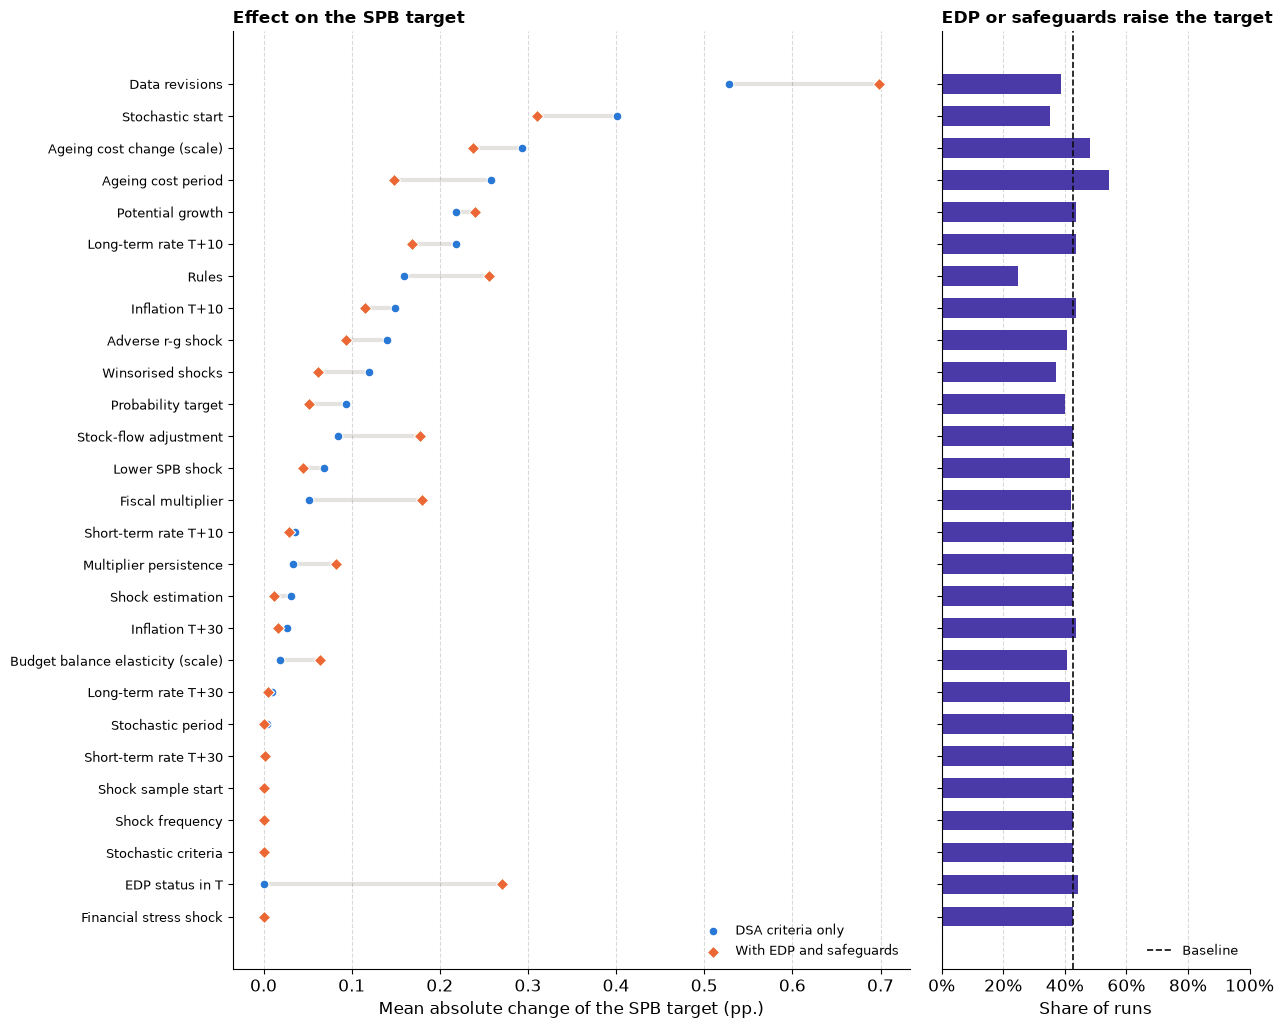

,group,dsa,binding,dsa_mean,binding_mean,share_above_dsa
check,,,,,,
Data revisions,Data,0.31,0.30,0.53,0.70,0.39
Short-term rate T+10,Macro,0.04,0.00,0.04,0.03,0.43
Long-term rate T+10,Macro,0.21,0.14,0.22,0.17,0.44
Short-term rate T+30,Macro,0.00,0.00,0.00,0.00,0.43
Long-term rate T+30,Macro,0.00,0.00,0.01,0.01,0.42
Inflation T+10,Macro,0.07,0.07,0.15,0.12,0.44
Inflation T+30,Macro,0.00,0.00,0.03,0.02,0.44
Potential growth,Macro,0.14,0.08,0.22,0.24,0.44
Ageing cost change (scale),Macro,0.23,0.08,0.29,0.24,0.48


In [18]:
plot_target_comparison(oat)
plt.show()
display(target_comparison(oat).set_index('check').drop(columns='baseline_share_above_dsa').round(2))

The heatmap and the tornado charts of section 1 for the binding target:

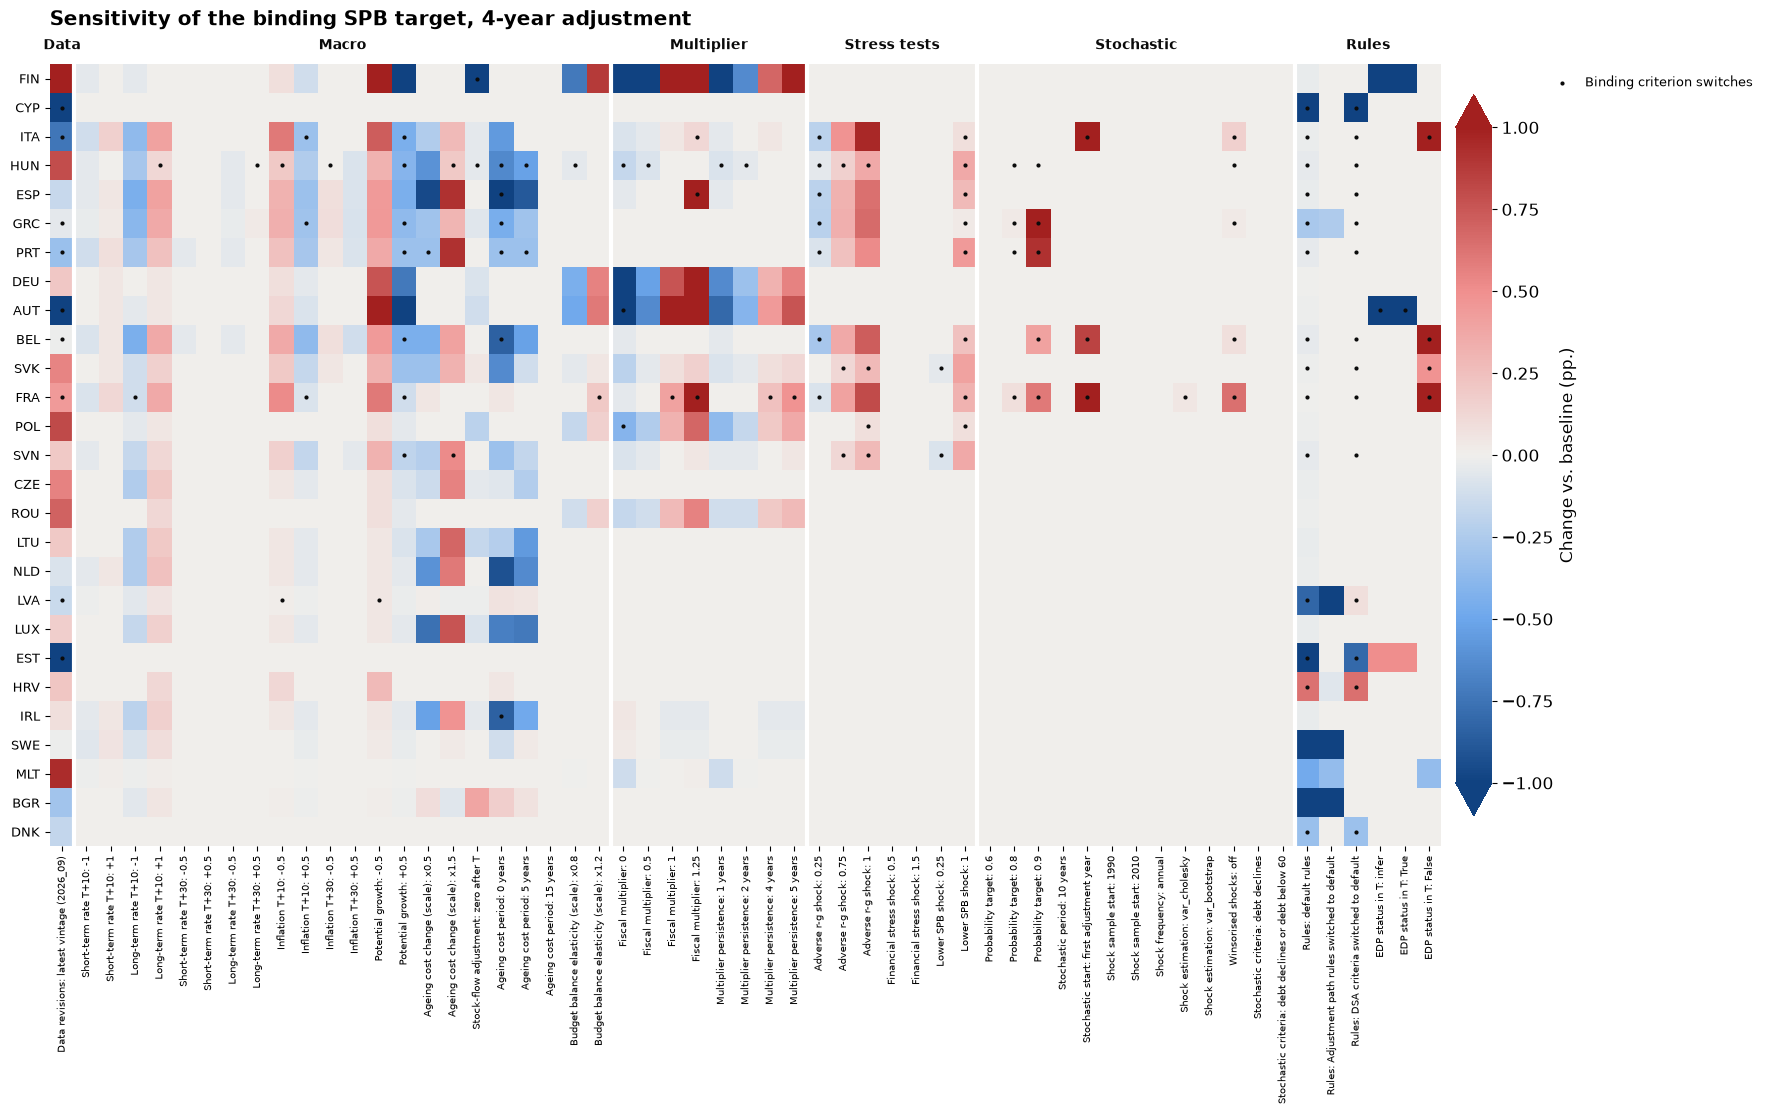

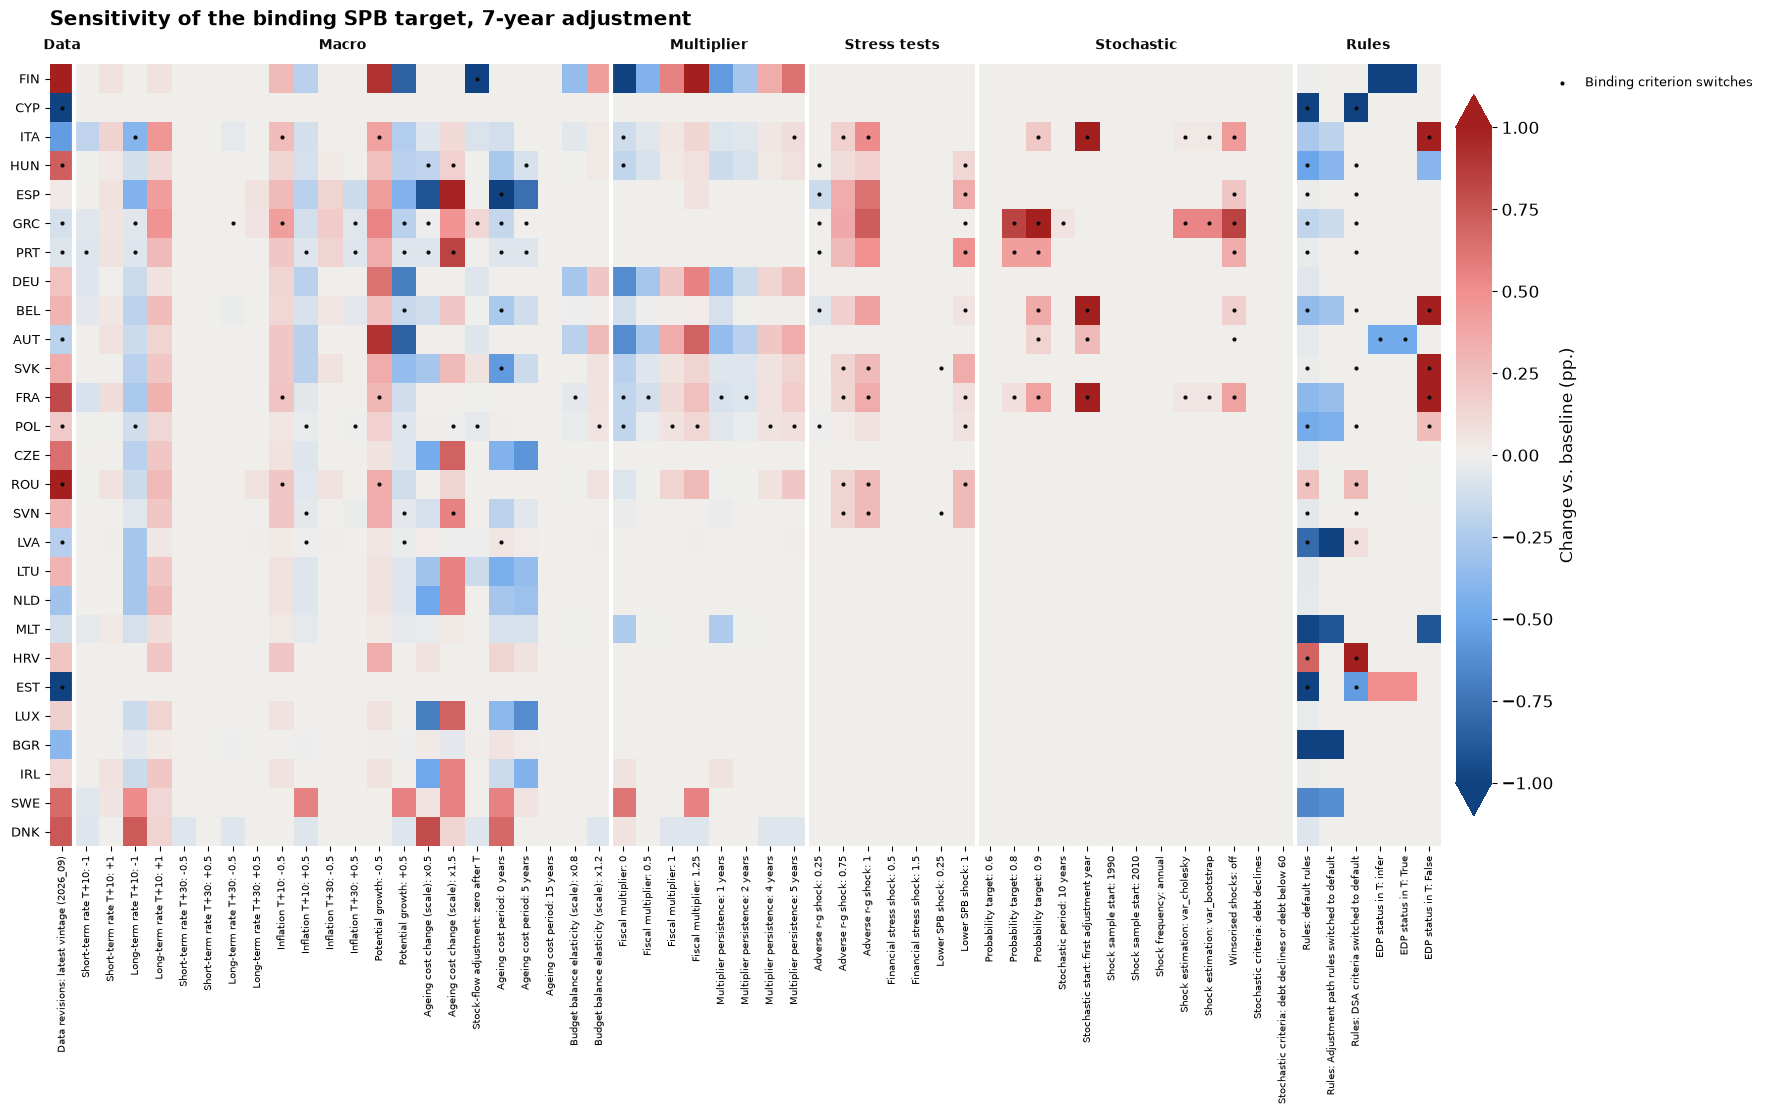

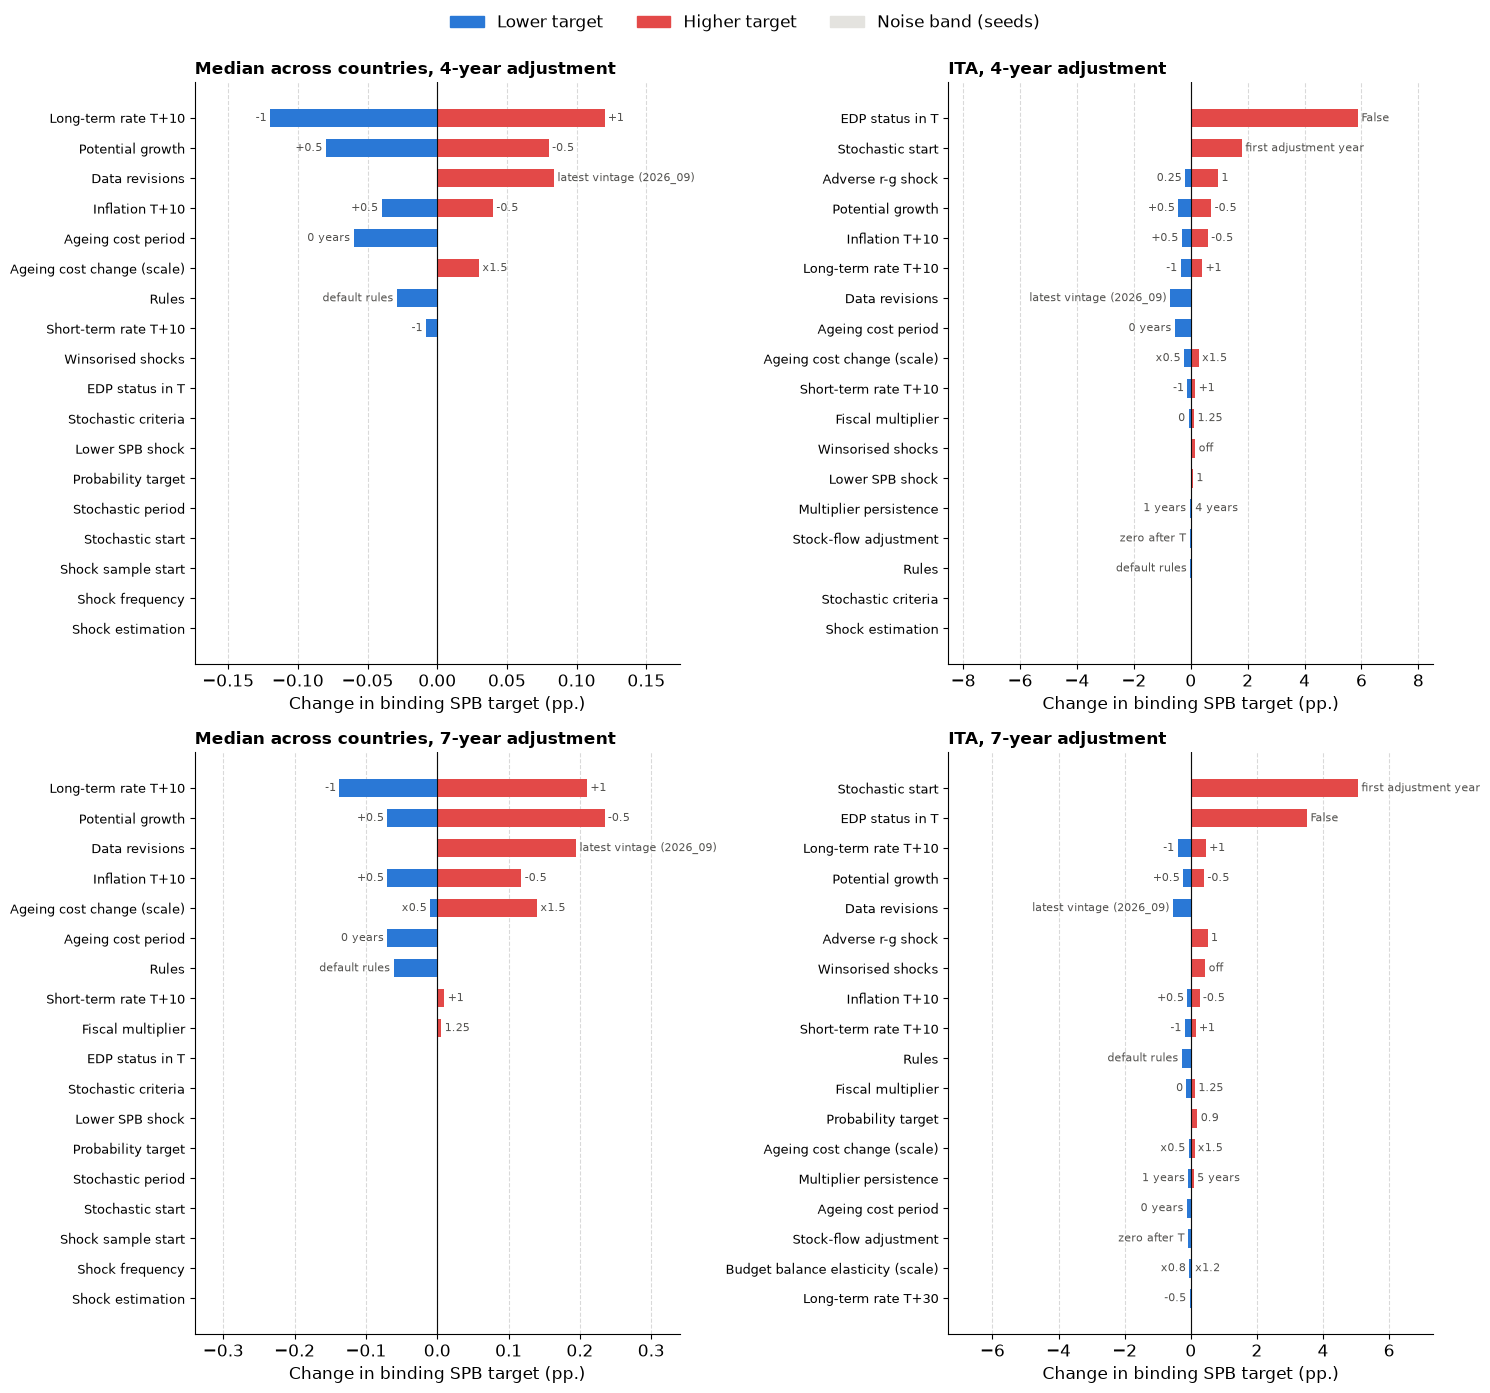

In [19]:
for n in ADJUSTMENT_PERIODS:
    plot_heatmap(oat[oat['group'] != 'Noise'], n, target='binding')
    plt.show()
tornado_grid('binding')

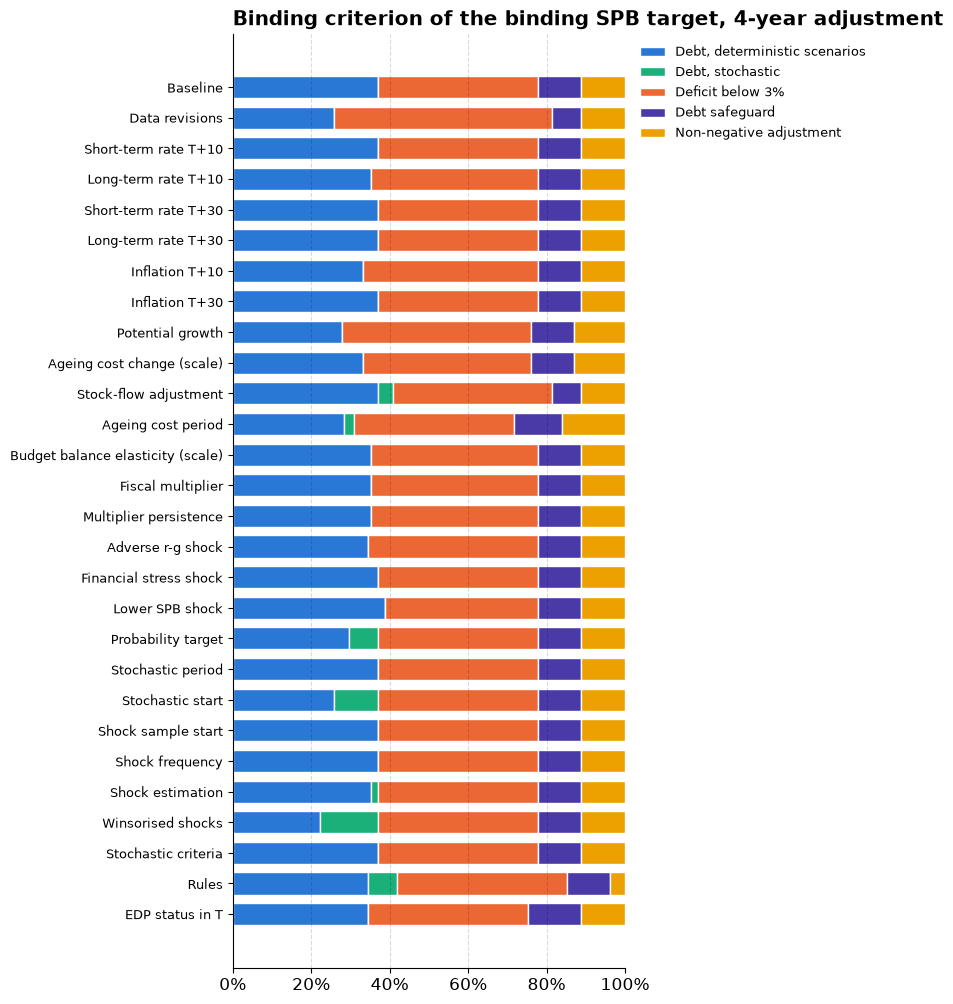

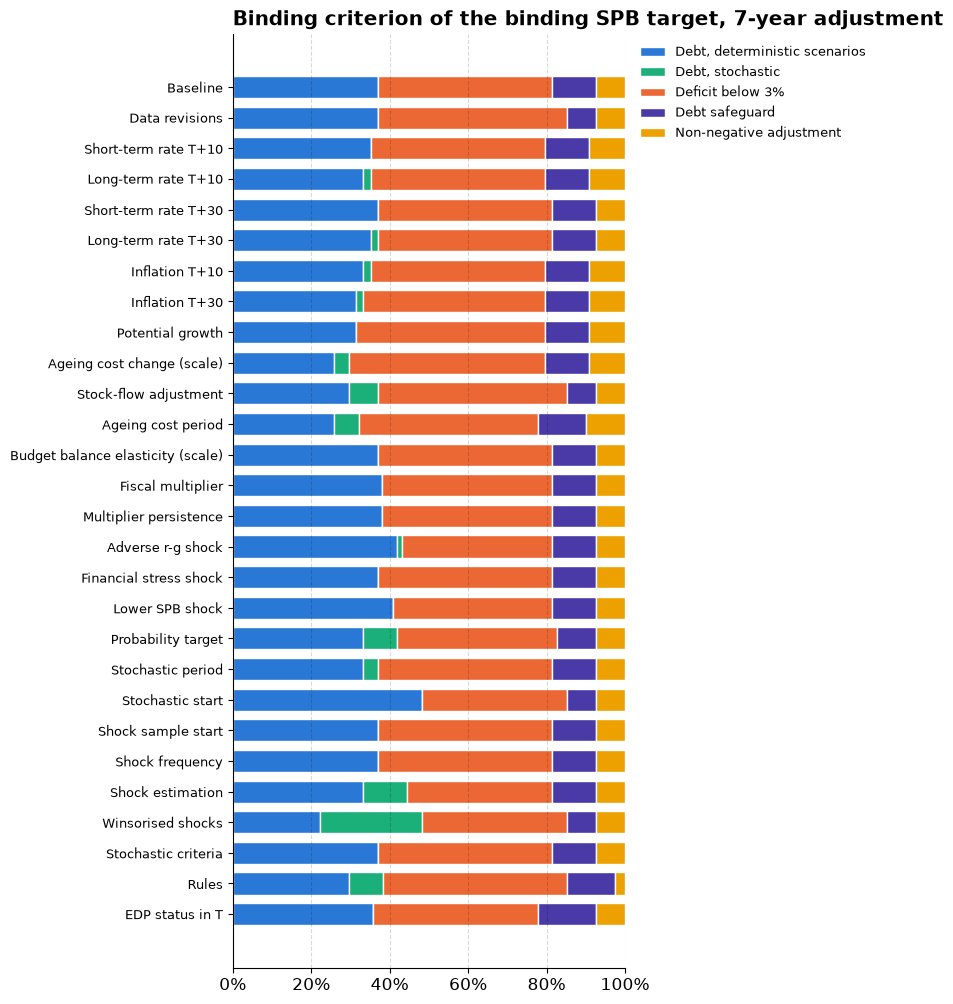

In [20]:
for n in ADJUSTMENT_PERIODS:
    plot_criterion_shares(oat, adjustment_period=n, target='binding')
    plt.show()

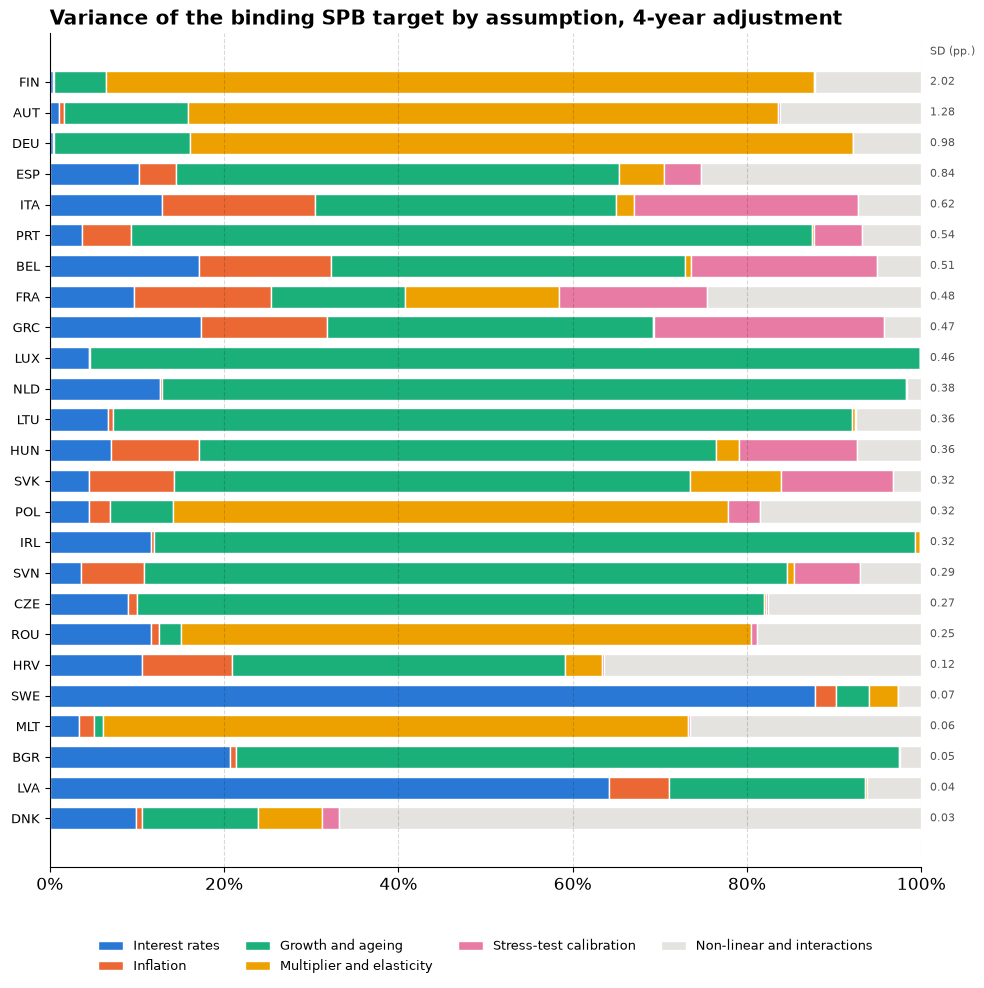

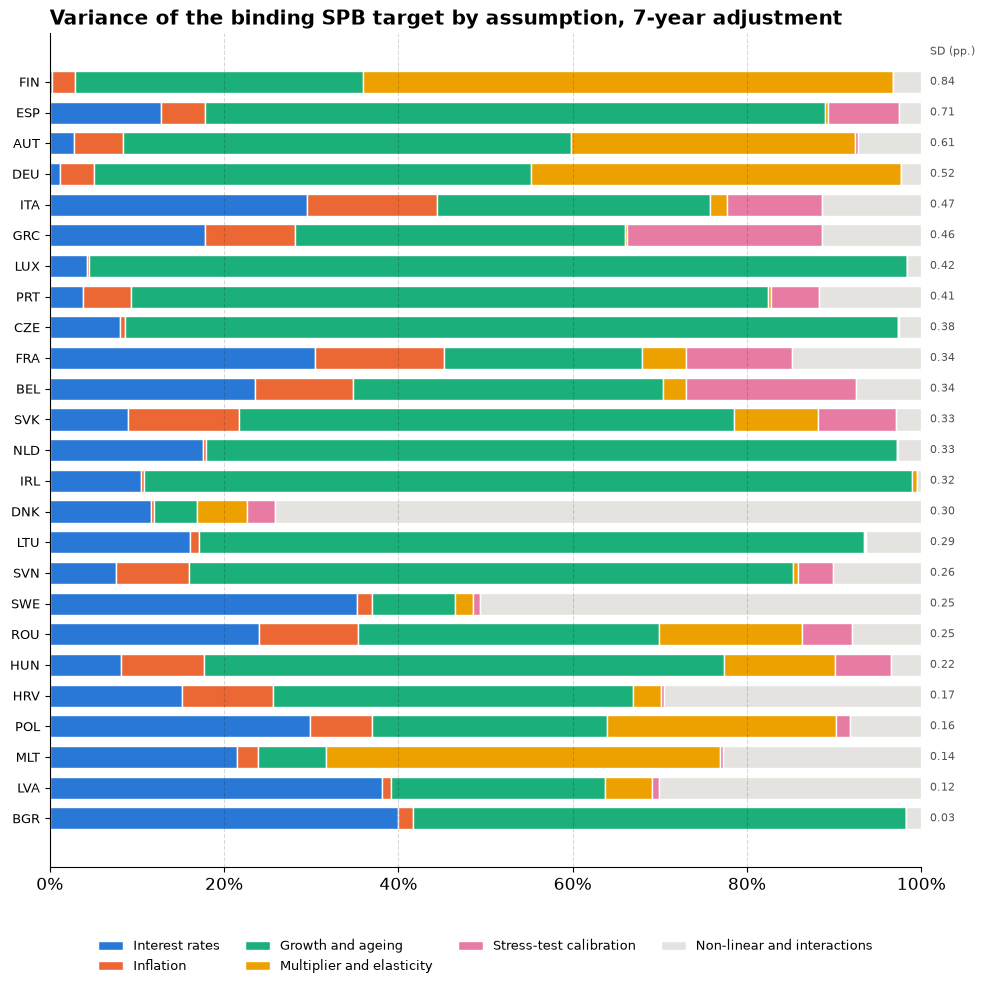

In [21]:
# Global sensitivity analysis for the binding target
for n in ADJUSTMENT_PERIODS:
    plot_variance_shares(vd[vd['target'] == 'binding'], adjustment_period=n)
    plt.show()

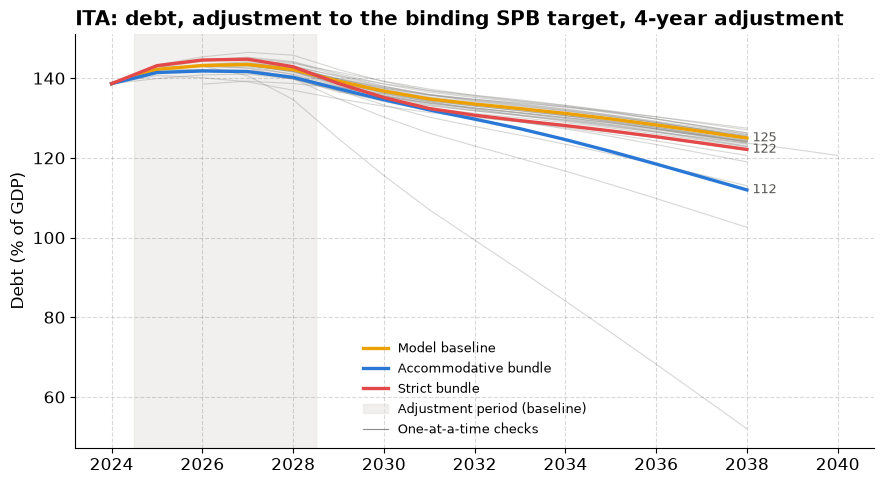

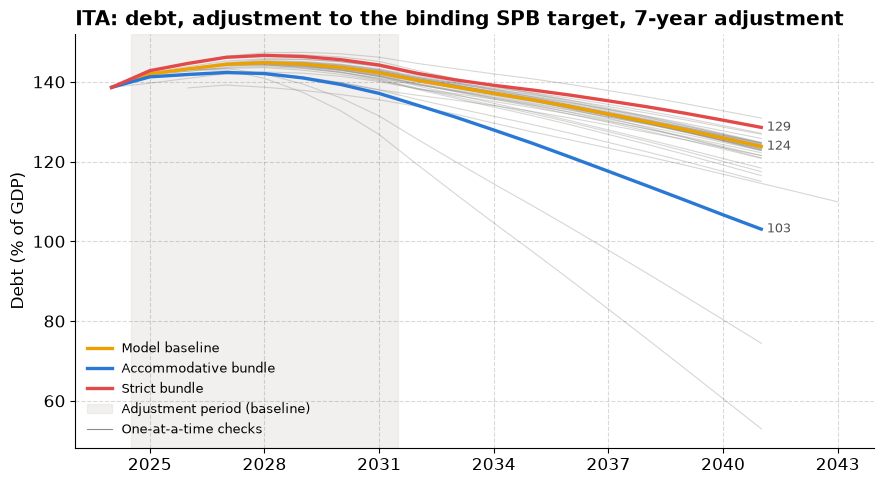

In [22]:
for n in ADJUSTMENT_PERIODS:
    plot_debt_paths(results, FOCUS_COUNTRY, adjustment_period=n, target='binding')
    plt.show()

## 5. Main findings

The numbers refer to the full run of September 2026 (EU27, 4- and 7-year adjustment periods). They change when the data, the baseline settings or the checks change.

1. **Most assumptions matter little on their own.** Across countries, periods and variants, no single macroeconomic assumption moves the DSA target by more than 0.3 pp. of GDP on average. The largest effects come from ageing costs (scale 0.29 pp., length of the period 0.26 pp.), potential growth (0.22 pp.) and the long-term interest rate at T+10 (0.22 pp.). The T+30 anchors, the stochastic period, the shock sample, the shock frequency and the financial stress calibration have almost no effect.
2. **Effects are concentrated in a few countries.** The median effect is zero for many checks, because only countries whose binding criterion reacts to an assumption respond. Countries at a floor or bound by the deficit criterion hardly move; high-debt countries bound by the debt criteria of the stress scenarios respond most.
3. **Data revisions matter more than any assumption.** Replacing the 2024 forecasts by the latest outturns changes the DSA target by 0.53 pp. on average (median close to zero, from −4.0 to +1.1 pp.).
4. **The stochastic analysis is robust to its technical settings but not to its timing.** Seeds, sample, frequency and estimation method hardly matter: the stochastic criterion rarely binds, and the noise band is close to zero. Starting the stochastic projection in the first adjustment year instead of the year after the adjustment period raises the target by up to 5 pp. (Italy, 7 years).
5. **The rules matter for a few countries with a large effect.** Switching the DSA criteria to the default implementation changes the target by more than 1.4 pp. in Cyprus and Estonia, where the non-negative adjustment floor of the Commission rules binds, and by 0.3 to 0.7 pp. in Croatia and Latvia, where the stochastic criterion becomes binding.
6. **The EDP and the safeguards dampen assumption effects and add their own.** They raise the target above the DSA target in 33% (4 years) and 52% (7 years) of baseline runs. Where they bind, most assumptions matter less (e.g. the ageing cost period: 0.26 pp. for the DSA target, 0.15 pp. for the binding target). The fiscal multiplier, the stock-flow adjustment and the EDP status work mainly through the safeguards: an EDP country treated as outside the EDP needs up to 6.6 pp. more (France, 4 years), because the debt safeguard then applies from the first year.
7. **Assumptions work additively.** In the global analysis, a linear model of the drawn assumptions explains 93% to 97% of the variance of the target (median across countries). Growth and ageing assumptions explain about half of it, interest rates 10% to 19%.
8. **Combined choices widen the range.** The strict and the accommodative bundle differ by 2 pp. of GDP for the median country (DSA target, 4 and 7 years) and by up to 4.6 pp.

## 6. Results

The tidy results (one row per run) and the tables above are saved to `output/sensitivity/sensitivity_results.xlsx`. Columns with dictionaries (SPB targets by criterion, debt paths) are kept in the cached runs (`*.pkl`).

In [23]:
flat = lambda df: df.drop(columns=[c for c in ['spb_target_dict', 'debt_path', 'dsa_debt_path'] if c in df])
with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_results.xlsx') as writer:
    flat(results).to_excel(writer, sheet_name='runs', index=False)
    effects.to_excel(writer, sheet_name='effects_dsa', index=False)
    effects_binding.to_excel(writer, sheet_name='effects_binding', index=False)
    target_comparison(oat).to_excel(writer, sheet_name='dsa_vs_binding', index=False)
    bundle_table.to_excel(writer, sheet_name='bundles', index=False)
    summary.to_excel(writer, sheet_name='bundle_targets')
    spec_table(oat_specs + [accommodative, strict]).to_excel(writer, sheet_name='specs')
    flat(glob).to_excel(writer, sheet_name='global_runs', index=False)
    vd.to_excel(writer, sheet_name='global_variance', index=False)
print(f"Saved to {OUTPUT_DIR / 'sensitivity_results.xlsx'}")

Saved to /home/user/eu-debt-sustainability-analysis/output/sensitivity/sensitivity_results.xlsx
